In [2]:
import spot

class SpotLTLMutator:
    # 1. Map Spot's built-in operator kinds to your category sets
    # spot.op_G (□), spot.op_F (♢), spot.op_X (◯), spot.op_Not (¬)
    UNARY_KINDS = {spot.op_G, spot.op_F, spot.op_X, spot.op_Not}
    
    # spot.op_Or (∨), spot.op_And (∧), spot.op_U (U), spot.op_R (R), spot.op_W (W)
    BINARY_KINDS = {spot.op_Or, spot.op_And, spot.op_U, spot.op_R, spot.op_W}
    
    # Allowed binary operators for Rule 3(d)
    RULE_3D_OPS = {spot.op_U, spot.op_W, spot.op_And, spot.op_Or}

    def __init__(self, atomic_propositions: list):
        """Initialize with a list of AP strings, e.g., ['p', 'q']"""
        self.ap_strings = set(atomic_propositions)
        self.ap_formulas = [spot.formula.ap(p) for p in atomic_propositions]
        self.constants = [spot.formula_ff(), spot.formula_tt()] # false, true

    def mutate(self, phi: spot.formula) -> list:
        """
        Main entry point. Takes a spot.formula object and returns 
        a deduplicated list of mutated spot.formula objects.
        """
        mutations = []
        phi_kind = phi.kind()

        # --- Structural Check Using Pure Explicit Kinds ---
        if phi_kind == spot.op_tt or phi_kind == spot.op_ff:
            mutations.extend(self._get_base_cases(phi, is_constant=True))
            
        elif phi_kind == spot.op_ap:
            mutations.extend(self._get_base_cases(phi, is_constant=False))
            
        elif phi_kind in self.UNARY_KINDS: 
            mutations.extend(self._get_unary_cases(phi))
            
        elif phi_kind in self.BINARY_KINDS: 
            mutations.extend(self._get_binary_cases(phi))

        # --- Apply General Cases (Rules 5 & 6) ---
        mutations.extend(self._get_general_cases(phi))

        # Deduplicate safely using unique string representations
        seen = set()
        deduped = []
        for m in mutations:
            f_str = m.to_str()
            if f_str not in seen:
                seen.add(f_str)
                deduped.append(m)
                
        return deduped

    def _get_base_cases(self, phi, is_constant: bool) -> list:
        """Handles Rules 1 and 2"""
        mutations = []
        if is_constant:
            # Rule 1: true -> false; false -> true
            mutations.append(spot.formula_ff() if phi.kind() == spot.op_tt else spot.formula_tt())
        else:
            # Rule 2: If p -> q where p != q
            p_str = phi.to_str()
            for q in self.ap_formulas:
                if q.to_str() != p_str:
                    mutations.append(q)
        return mutations

    def _get_unary_cases(self, phi: spot.formula) -> list:
        """Handles Rule 3 (Inductive Unary)"""
        mutations = []
        op1 = phi.kind()
        phi1 = phi[0]  # Safely get structural sub-operand
        
        # (a) phi' = op1' phi1
        for op1_prime in self.UNARY_KINDS:
            if op1 != op1_prime:
                mutations.append(spot.formula_unop(op1_prime, phi1))
                
        # (b) phi' = phi1
        mutations.append(phi1)
        
        # (c) phi' = op1 mutate(phi1)
        for m in self.mutate(phi1):
            mutations.append(spot.formula_unop(op1, m))
            
        # (d) phi' = p op2' phi
        for p in self.ap_formulas:
            for op2_prime in self.RULE_3D_OPS:
                mutations.append(spot.formula_binop(op2_prime, p, phi))
                
        return mutations

    def _get_binary_cases(self, phi: spot.formula) -> list:
        """Handles Rule 4 (Inductive Binary)"""
        mutations = []
        op2 = phi.kind()
        phi1 = phi[0]  # Left sub-operand
        phi2 = phi[1]  # Right sub-operand
        
        # (a) phi' = phi1 op2' phi2
        for op2_prime in self.BINARY_KINDS:
            if op2 != op2_prime:
                mutations.append(spot.formula_binop(op2_prime, phi1, phi2))
                
        # (b) phi' = phi_i
        mutations.append(phi1)
        mutations.append(phi2)
        
        # (c) phi' = mutate(phi1) op2 phi2
        for m in self.mutate(phi1):
            mutations.append(spot.formula_binop(op2, m, phi2))
            
        # (d) phi' = phi1 op2 mutate(phi2)
        for m in self.mutate(phi2):
            mutations.append(spot.formula_binop(op2, phi1, m))
            
        return mutations

    def _get_general_cases(self, phi: spot.formula) -> list:
        """Handles Rules 5 and 6 (General Cases)"""
        mutations = []
        
        # Rule 5: wrap the whole formula in a unary operator
        for op1 in self.UNARY_KINDS:
            mutations.append(spot.formula_unop(op1, phi))
            
        # Rule 6: Replace with true, false, or any AP
        mutations.extend(self.constants)
        mutations.extend(self.ap_formulas)
        
        return mutations


# --- Example Tester Verification ---
if __name__ == "__main__":
    mutator = SpotLTLMutator(atomic_propositions=["p", "q"])
    
    # Parse a test formula string cleanly using Spot syntax
    input_formula = spot.formula("G(p | F q)")
    
    print(f"Original Spot Formula: {input_formula}")
    print("-" * 50)
    
    results = mutator.mutate(input_formula)
    print(f"Generated {len(results)} distinct mutants via Spot API:\n")
    
    for m in sorted(results, key=lambda x: x.to_str())[:15]: 
        print(f"  -> {m.to_str()}")

: 

In [1]:
{spot.op_G, spot.op_F, spot.op_X, spot.op_Not}
{spot.op_Or, spot.op_And, spot.op_U, spot.op_R, spot.op_W}
{spot.op_U, spot.op_W, spot.op_And, spot.op_Or}

NameError: name 'spot' is not defined

In [6]:
import spot


class LTLMutator:
    """
    Definition 9 LTL mutator.

    Given a Spot formula φ, returns ALL possible one-step mutations φ'
    allowed by the definition.
    """

    UNARY_OPS = ["!", "X", "F", "G"]
    BINARY_OPS = ["|", "&", "U", "R", "W"]

    def __init__(self, ap_set=None):
        """
        Parameters
        ----------
        ap_set : iterable[str] or None

            AP from the definition.

            If None, AP is inferred from the formula.
        """
        self.ap_set = set(ap_set) if ap_set is not None else None

    # ============================================================
    # Public API
    # ============================================================

    def mutate(self, formula):
        """
        Return all possible mutations of formula.
        """
        aps = self.ap_set or self.extract_aps(formula)

        mutations = set()

        # General cases (5) and (6)
        mutations |= self.general_case_5(formula)
        mutations |= self.general_case_6(aps)

        # Syntax-directed cases
        mutations |= self._mutate_recursive(formula, aps)

        mutations.discard(str(formula))
        return {spot.formula(m) for m in mutations}

    # ============================================================
    # AP extraction
    # ============================================================

    def extract_aps(self, formula):
        aps = set()

        def visit(f):
            if f.kind() == spot.op_ap:
                aps.add(f.ap_name())
            else:
                for c in f:
                    visit(c)

        visit(formula)
        return aps

    # ============================================================
    # Recursive mutation dispatcher
    # ============================================================

    def _mutate_recursive(self, phi, aps):
        k = phi.kind()

        if k == spot.op_tt:
            return self.base_case_true()

        if k == spot.op_ff:
            return self.base_case_false()

        if k == spot.op_ap:
            return self.base_case_ap(phi, aps)

        unary_map = {
            spot.op_Not: "!",
            spot.op_X: "X",
            spot.op_F: "F",
            spot.op_G: "G",
        }

        if k in unary_map:
            return self.unary_cases(phi, unary_map[k], aps)

        binary_map = {
            spot.op_Or: "|",
            spot.op_And: "&",
            spot.op_U: "U",
            spot.op_R: "R",
            spot.op_W: "W",
        }

        if k in binary_map:
            return self.binary_cases(phi, binary_map[k], aps)

        return set()

    # ============================================================
    # Base cases
    # ============================================================

    def base_case_true(self):
        # Definition 9.1
        return {"false"}

    def base_case_false(self):
        # Definition 9.1
        return {"true"}

    def base_case_ap(self, phi, aps):
        # Definition 9.2
        p = phi.ap_name()

        return {
            q
            for q in aps
            if q != p
        }

    # ============================================================
    # Case 3: unary formulas
    # ============================================================

    def unary_cases(self, phi, op, aps):
        child = phi[0]

        results = set()

        # 3(a)
        results |= self.unary_replace_operator(op, child)

        # 3(b)
        results.add(str(child))

        # 3(c)
        results |= self.unary_mutate_child(op, child, aps)

        # 3(d)
        results |= self.unary_extend_with_binary(phi, aps)

        return results

    def unary_replace_operator(self, op, child):
        result = set()

        for op2 in self.UNARY_OPS:
            if op2 != op:
                result.add(f"{op2}({child})")

        return result

    def unary_mutate_child(self, op, child, aps):
        result = set()

        for m in self._mutate_recursive(child, aps):
            result.add(f"{op}({m})")

        return result

    def unary_extend_with_binary(self, phi, aps):
        result = set()

        for p in aps:
            for bop in ["U", "W", "&", "|"]:
                result.add(f"({p}) {bop} ({phi})")

        return result

    # ============================================================
    # Case 4: binary formulas
    # ============================================================

    def binary_cases(self, phi, op, aps):
        left = phi[0]
        right = phi[1]

        results = set()

        # 4(a)
        results |= self.binary_replace_operator(left, op, right)

        # 4(b)
        results.add(str(left))
        results.add(str(right))

        # 4(c)
        results |= self.binary_mutate_left(left, op, right, aps)

        # 4(d)
        results |= self.binary_mutate_right(left, op, right, aps)

        return results

    def binary_replace_operator(self, left, op, right):
        result = set()

        for op2 in self.BINARY_OPS:
            if op2 != op:
                result.add(f"({left}) {op2} ({right})")

        return result

    def binary_mutate_left(self, left, op, right, aps):
        result = set()

        for m in self._mutate_recursive(left, aps):
            result.add(f"({m}) {op} ({right})")

        return result

    def binary_mutate_right(self, left, op, right, aps):
        result = set()

        for m in self._mutate_recursive(right, aps):
            result.add(f"({left}) {op} ({m})")

        return result

    # ============================================================
    # General cases
    # ============================================================

    def general_case_5(self, phi):
        result = set()

        for op in self.UNARY_OPS:
            result.add(f"{op}({phi})")

        return result

    def general_case_6(self, aps):
        result = {"true", "false"}

        result.update(aps)

        return result

In [4]:
f = spot.formula("G(a U b)")

mutator = LTLMutator()

mutations = mutator.mutate(f)

print(f"Number of mutations: {len(mutations)}")
for m in sorted(map(str, mutations)):
    print(m)

Number of mutations: 26
!(a U b)
!G(a U b)
0
1
F(a U b)
FG(a U b)
G(a & b)
G(a R b)
G(a U b)
G(a W b)
G(a | b)
Ga
Gb
X(a U b)
XG(a U b)
a
a & G(a U b)
a U G(a U b)
a U b
a W G(a U b)
a | G(a U b)
b
b & G(a U b)
b U G(a U b)
b W G(a U b)
b | G(a U b)


In [7]:
from collections import deque


def mutation_distance_bidirectional(
    source,
    target,
    mutator,
    max_depth=20
):
    s = str(source)
    t = str(target)

    if s == t:
        return 0

    front_a = {s: 0}
    front_b = {t: 0}

    queue_a = deque([source])
    queue_b = deque([target])

    while queue_a and queue_b:

        if len(queue_a) <= len(queue_b):

            for _ in range(len(queue_a)):
                current = queue_a.popleft()

                d = front_a[str(current)]

                if d >= max_depth:
                    continue

                for nxt in mutator.mutate(current):

                    ns = str(nxt)

                    if ns in front_b:
                        return d + 1 + front_b[ns]

                    if ns not in front_a:
                        front_a[ns] = d + 1
                        queue_a.append(nxt)

        else:

            for _ in range(len(queue_b)):
                current = queue_b.popleft()

                d = front_b[str(current)]

                if d >= max_depth:
                    continue

                for nxt in mutator.mutate(current):

                    ns = str(nxt)

                    if ns in front_a:
                        return d + 1 + front_a[ns]

                    if ns not in front_b:
                        front_b[ns] = d + 1
                        queue_b.append(nxt)

    return None

In [8]:
import spot
f1 = spot.formula("G(a & (F b)) -> ((!c) U d)")
f2 = spot.formula("F(a)& (G b) -> ((!d) U b)")

mutator = LTLMutator()

d = mutation_distance_bidirectional(f1, f2, mutator)

print(d)

2


In [12]:

mutator = LTLMutator()

mutations = mutator.mutate(f2)

print(f"Number of mutations: {len(mutations)}")
for m in sorted(map(str, mutations)):
    print(m)


Number of mutations: 9
!((Fa & Gb) -> (!d U b))
0
1
F((Fa & Gb) -> (!d U b))
G((Fa & Gb) -> (!d U b))
X((Fa & Gb) -> (!d U b))
a
b
d


In [1]:
import spot

def mutate_ltl(phi: spot.formula, AP: set) -> set:
    """
    Mutates an LTL formula based on Definition 9.
    Returns a set of mutated spot.formula objects.
    """
    mutants = set()
    
    # ---------------------------------------------------------
    # Helper definitions for Spot operator mappings
    # ---------------------------------------------------------
    unary_factories = {
        spot.op_Not: spot.formula.Not,
        spot.op_X:   spot.formula.X,    # Next / Circle
        spot.op_F:   spot.formula.F,    # Eventually / Diamond
        spot.op_G:   spot.formula.G     # Always / Square
    }
    
    # Note: Spot's And/Or are n-ary. We use lists to construct them.
    binary_factories = {
        spot.op_U:   spot.formula.U,
        spot.op_R:   spot.formula.R,
        spot.op_W:   spot.formula.W,
        spot.op_And: lambda left, right: spot.formula.And([left, right]),
        spot.op_Or:  lambda left, right: spot.formula.Or([left, right])
    }

    # ==========================================
    # GENERAL CASES (Rules 5 & 6)
    # ==========================================
    
    # Rule 5: Wrap in Unary
    for factory in unary_factories.values():
        mutants.add(factory(phi))
        
    # Rule 6: Replace with constants or APs
    mutants.add(spot.formula.tt()) # true
    mutants.add(spot.formula.ff()) # false
    for p in AP:
        mutants.add(spot.formula.ap(p))

    # ==========================================
    # BASE & INDUCTIVE CASES
    # ==========================================
    kind = phi.kind()

    # Base Rule 1: Constants
    if kind == spot.op_tt:
        mutants.add(spot.formula.ff())
    elif kind == spot.op_ff:
        mutants.add(spot.formula.tt())
        
    # Base Rule 2: Atomic Propositions
    elif kind == spot.op_ap:
        p_name = phi.ap_name()
        for q in AP:
            if q != p_name:
                mutants.add(spot.formula.ap(q))

    # Inductive Rule 3: Unary Operators
    elif kind in unary_factories:
        child = phi[0] # Get the single child of the unary operator
        
        # (a) Swap operator
        for op, factory in unary_factories.items():
            if op != kind:
                mutants.add(factory(child))
                
        # (b) Drop operator entirely
        mutants.add(child)
        
        # (c) Mutate child
        for m in mutate_ltl(child, AP):
            mutants.add(unary_factories[kind](m))
            
        # (d) Prepend Binary: p op_2' phi
        for p in AP:
            for op, factory in binary_factories.items():
                if op in [spot.op_U, spot.op_W, spot.op_And, spot.op_Or]:
                    mutants.add(factory(spot.formula.ap(p), phi))

    # Inductive Rule 4: Binary Operators
    # Warning: Spot collapses (a & b & c) into a single n-ary node. 
    # For strict adherence, we treat the first child as 'left' and the rest as 'right'.
    elif kind in binary_factories or kind in [spot.op_And, spot.op_Or]:
        if phi.size() >= 2:
            left = phi[0]
            # Handle n-ary Or/And by grouping the remaining children
            if kind == spot.op_And and phi.size() > 2:
                right = spot.formula.And([phi[i] for i in range(1, phi.size())])
            elif kind == spot.op_Or and phi.size() > 2:
                right = spot.formula.Or([phi[i] for i in range(1, phi.size())])
            else:
                right = phi[1]
            
            # (a) Swap operator
            for op, factory in binary_factories.items():
                if op != kind:
                    mutants.add(factory(left, right))
                    
            # (b) Drop operator (yield children)
            mutants.add(left)
            mutants.add(right)
            
            # (c) Mutate left child
            for m in mutate_ltl(left, AP):
                mutants.add(binary_factories.get(kind, binary_factories[spot.op_And])(m, right))
                
            # (d) Mutate right child
            for m in mutate_ltl(right, AP):
                mutants.add(binary_factories.get(kind, binary_factories[spot.op_And])(left, m))

    return mutants

In [6]:
# --- Usage Example ---

formula_str = "G(p -> F q)"

# 1. Parse the formula
phi = spot.formula(formula_str)
print(f"Original Formula: {phi}\n")

# 2. Extract Atomic Propositions automatically
# spot.atomic_prop_collect returns a set of spot.formula objects, 
# we just want their string names for our AP set.
ap_set = {ap.ap_name() for ap in spot.atomic_prop_collect(phi)}

# If you want to introduce new APs not in the formula, add them here
# ap_set.add("r")

# 3. Generate Mutants
mutants = mutate_ltl(phi, ap_set)

# 4. Print Results
print(f"Generated {len(mutants)} mutants:")
for idx, m in enumerate(mutants, 1):
    # Spot automatically formats standard LTL strings
    print(f"{idx:3d}: {m}")
    
# Optional: Filter out semantically equivalent mutants
print("\n--- Applying Simplification ---")
simplified_mutants = {spot.simplify(m) for m in mutants}
print(f"Reduced to {len(simplified_mutants)} unique behavioral formulas.")

Original Formula: G(p -> Fq)

Generated 25 mutants:
  1: 0
  2: 1
  3: p
  4: q
  5: p -> Fq
  6: G(p -> Fq)
  7: !G(p -> Fq)
  8: XG(p -> Fq)
  9: FG(p -> Fq)
 10: !(p -> Fq)
 11: X(p -> Fq)
 12: F(p -> Fq)
 13: Gp
 14: Gq
 15: G!(p -> Fq)
 16: GX(p -> Fq)
 17: GF(p -> Fq)
 18: p U G(p -> Fq)
 19: p W G(p -> Fq)
 20: p & G(p -> Fq)
 21: p | G(p -> Fq)
 22: q U G(p -> Fq)
 23: q W G(p -> Fq)
 24: q & G(p -> Fq)
 25: q | G(p -> Fq)

--- Applying Simplification ---
Reduced to 24 unique behavioral formulas.


In [10]:
simplified_mutants

{spot.formula("0"),
 spot.formula("1"),
 spot.formula("p"),
 spot.formula("q"),
 spot.formula("Gp"),
 spot.formula("Gq"),
 spot.formula("!p | Fq"),
 spot.formula("G(!p | Fq)"),
 spot.formula("p & G!q"),
 spot.formula("F(p & G!q)"),
 spot.formula("XG(!p | Fq)"),
 spot.formula("FG(!p | Fq)"),
 spot.formula("X(!p | Fq)"),
 spot.formula("F(!p | q)"),
 spot.formula("G(p & !q)"),
 spot.formula("GF(!p | q)"),
 spot.formula("p U G(!p | Fq)"),
 spot.formula("p W G(!p | Fq)"),
 spot.formula("p & G(!p | Fq)"),
 spot.formula("p | G(!p | Fq)"),
 spot.formula("q U G(!p | Fq)"),
 spot.formula("q W G(!p | Fq)"),
 spot.formula("q & G(!p | Fq)"),
 spot.formula("q | G(!p | Fq)")}

In [14]:
formula_str = "G(p -> F q)"
formula_str = "G(!p | F q)"
phi = spot.formula(formula_str) 
AP =  set({'p', 'q'})

mutants = set()
    
# ---------------------------------------------------------
# Helper definitions for Spot operator mappings
# ---------------------------------------------------------
unary_factories = {
    spot.op_Not: spot.formula.Not,
    spot.op_X:   spot.formula.X,    # Next / Circle
    spot.op_F:   spot.formula.F,    # Eventually / Diamond
    spot.op_G:   spot.formula.G     # Always / Square
}

# Note: Spot's And/Or are n-ary. We use lists to construct them.
binary_factories = {
    spot.op_U:   spot.formula.U,
    spot.op_R:   spot.formula.R,
    spot.op_W:   spot.formula.W,
    spot.op_And: lambda left, right: spot.formula.And([left, right]),
    spot.op_Or:  lambda left, right: spot.formula.Or([left, right])
}

# ==========================================
# GENERAL CASES (Rules 5 & 6)
# ==========================================

# Rule 5: Wrap in Unary
for factory in unary_factories.values():
    mutants.add(factory(phi))
    
# Rule 6: Replace with constants or APs
mutants.add(spot.formula.tt()) # true
mutants.add(spot.formula.ff()) # false
for p in AP:
    mutants.add(spot.formula.ap(p))

# ==========================================
# BASE & INDUCTIVE CASES
# ==========================================
kind = phi.kind()

# Base Rule 1: Constants
if kind == spot.op_tt:
    mutants.add(spot.formula.ff())
elif kind == spot.op_ff:
    mutants.add(spot.formula.tt())
    
# Base Rule 2: Atomic Propositions
elif kind == spot.op_ap:
    p_name = phi.ap_name()
    for q in AP:
        if q != p_name:
            mutants.add(spot.formula.ap(q))

# Inductive Rule 3: Unary Operators
elif kind in unary_factories:
    child = phi[0] # Get the single child of the unary operator
    
    # (a) Swap operator
    for op, factory in unary_factories.items():
        if op != kind:
            mutants.add(factory(child))
            
    # (b) Drop operator entirely
    mutants.add(child)
    
    # (c) Mutate child
    for m in mutate_ltl(child, AP):
        mutants.add(unary_factories[kind](m))
        
    # (d) Prepend Binary: p op_2' phi
    for p in AP:
        for op, factory in binary_factories.items():
            if op in [spot.op_U, spot.op_W, spot.op_And, spot.op_Or]:
                mutants.add(factory(spot.formula.ap(p), phi))

# Inductive Rule 4: Binary Operators
# Warning: Spot collapses (a & b & c) into a single n-ary node. 
# For strict adherence, we treat the first child as 'left' and the rest as 'right'.
elif kind in binary_factories or kind in [spot.op_And, spot.op_Or]:
    if phi.size() >= 2:
        left = phi[0]
        # Handle n-ary Or/And by grouping the remaining children
        if kind == spot.op_And and phi.size() > 2:
            right = spot.formula.And([phi[i] for i in range(1, phi.size())])
        elif kind == spot.op_Or and phi.size() > 2:
            right = spot.formula.Or([phi[i] for i in range(1, phi.size())])
        else:
            right = phi[1]
        
        # (a) Swap operator
        for op, factory in binary_factories.items():
            if op != kind:
                mutants.add(factory(left, right))
                
        # (b) Drop operator (yield children)
        mutants.add(left)
        mutants.add(right)
        
        # (c) Mutate left child
        for m in mutate_ltl(left, AP):
            mutants.add(binary_factories.get(kind, binary_factories[spot.op_And])(m, right))
            
        # (d) Mutate right child
        for m in mutate_ltl(right, AP):
            mutants.add(binary_factories.get(kind, binary_factories[spot.op_And])(left, m))

mutants

{spot.formula("0"),
 spot.formula("1"),
 spot.formula("p"),
 spot.formula("q"),
 spot.formula("Gp"),
 spot.formula("Gq"),
 spot.formula("!p | Fq"),
 spot.formula("G(!p | Fq)"),
 spot.formula("XG(!p | Fq)"),
 spot.formula("FG(!p | Fq)"),
 spot.formula("X(!p | Fq)"),
 spot.formula("p U G(!p | Fq)"),
 spot.formula("p W G(!p | Fq)"),
 spot.formula("p & G(!p | Fq)"),
 spot.formula("p | G(!p | Fq)"),
 spot.formula("q U G(!p | Fq)"),
 spot.formula("q W G(!p | Fq)"),
 spot.formula("q & G(!p | Fq)"),
 spot.formula("q | G(!p | Fq)"),
 spot.formula("!G(!p | Fq)"),
 spot.formula("!(!p | Fq)"),
 spot.formula("F(!p | Fq)"),
 spot.formula("G!p"),
 spot.formula("GFq"),
 spot.formula("G(!p | q)"),
 spot.formula("G!(!p | Fq)"),
 spot.formula("GF(!p | Fq)"),
 spot.formula("G(!p U Fq)"),
 spot.formula("G(!p R Fq)"),
 spot.formula("G(!p W Fq)"),
 spot.formula("G(!p & Fq)"),
 spot.formula("G(p | Fq)"),
 spot.formula("G(q | Fq)"),
 spot.formula("G(!p | q | Fq)"),
 spot.formula("G(Fq | X!p)"),
 spot.formula("

In [ ]:
"""
LTL Formula Mutation — Definition 9
====================================
Implements mutate(φ, AP) returning the *complete set* of one-step syntactic
mutations of an LTL formula, following Definition 9 rule-by-rule.

Operator encoding
-----------------
  Unary  : 'neg'  (¬)   'next' (○)   'F' (◇)   'G' (□)
  Binary : 'or'   (∨)   'and'  (∧)   'U'        'R'      'W'

Quick start
-----------
    ap  = ('p', 'q')
    phi = UnaryOp('G', Atom('p'))          # □p
    for m in sorted(mutate(phi, ap), key=repr):
        print(m)
"""

from __future__ import annotations
from typing import Sequence, Set

# ---------------------------------------------------------------------------
# Operator pools
# ---------------------------------------------------------------------------
UNARY_OPS  = frozenset({'neg', 'next', 'F', 'G'})      # ¬  ○  ◇  □
BINARY_OPS = frozenset({'or', 'and', 'U', 'R', 'W'})   # ∨  ∧  U  R  W
BINARY_3D  = frozenset({'U', 'W', 'and', 'or'})        # subset for Case 3(d)

_SYM: dict[str, str] = {
    'neg': '¬', 'next': '○', 'F': '◇', 'G': '□',
    'or':  '∨', 'and':  '∧', 'U': 'U', 'R': 'R', 'W': 'W',
}


# ---------------------------------------------------------------------------
# Formula AST
# ---------------------------------------------------------------------------

class Formula:
    """Abstract base for all LTL formula nodes."""
    def mutants(self, ap: Sequence[str]) -> Set['Formula']:
        """Convenience wrapper: return mutate(self, ap)."""
        return mutate(self, ap)


class Const(Formula):
    """Boolean constant — Const(True) = true, Const(False) = false."""
    __slots__ = ('value',)

    def __init__(self, value: bool) -> None:
        self.value = bool(value)

    def __repr__(self) -> str:
        return 'true' if self.value else 'false'

    def __eq__(self, other: object) -> bool:
        return isinstance(other, Const) and self.value == other.value

    def __hash__(self) -> int:
        return hash(('Const', self.value))


class Atom(Formula):
    """Atomic proposition  p ∈ AP."""
    __slots__ = ('name',)

    def __init__(self, name: str) -> None:
        self.name = str(name)

    def __repr__(self) -> str:
        return self.name

    def __eq__(self, other: object) -> bool:
        return isinstance(other, Atom) and self.name == other.name

    def __hash__(self) -> int:
        return hash(('Atom', self.name))


class UnaryOp(Formula):
    """Unary formula  op child,  op ∈ {'neg','next','F','G'}."""
    __slots__ = ('op', 'child')

    def __init__(self, op: str, child: Formula) -> None:
        if op not in UNARY_OPS:
            raise ValueError(f"Unary op must be one of {sorted(UNARY_OPS)}, got {op!r}")
        self.op    = op
        self.child = child

    def __repr__(self) -> str:
        # Parenthesise binary sub-formulas for unambiguous display
        c = f'({self.child})' if isinstance(self.child, BinaryOp) else repr(self.child)
        return f'{_SYM[self.op]}{c}'

    def __eq__(self, other: object) -> bool:
        return (isinstance(other, UnaryOp)
                and self.op == other.op
                and self.child == other.child)

    def __hash__(self) -> int:
        return hash(('UnaryOp', self.op, self.child))


class BinaryOp(Formula):
    """Binary formula  left op right,  op ∈ {'or','and','U','R','W'}."""
    __slots__ = ('op', 'left', 'right')

    def __init__(self, op: str, left: Formula, right: Formula) -> None:
        if op not in BINARY_OPS:
            raise ValueError(f"Binary op must be one of {sorted(BINARY_OPS)}, got {op!r}")
        self.op    = op
        self.left  = left
        self.right = right

    def __repr__(self) -> str:
        return f'({self.left} {_SYM[self.op]} {self.right})'

    def __eq__(self, other: object) -> bool:
        return (isinstance(other, BinaryOp)
                and self.op == other.op
                and self.left == other.left
                and self.right == other.right)

    def __hash__(self) -> int:
        return hash(('BinaryOp', self.op, self.left, self.right))


# ---------------------------------------------------------------------------
# mutate — Definition 9
# ---------------------------------------------------------------------------

def mutate(phi: Formula, ap: Sequence[str]) -> Set[Formula]:
    """
    Return the complete set of mutations of φ following Definition 9 exactly.

    Every applicable rule from the definition is applied; the original
    formula φ is removed from the result (a mutation must be distinct).

    Parameters
    ----------
    phi : Formula
        The LTL formula to mutate.
    ap  : Sequence[str]
        The alphabet of atomic proposition names (AP).

    Returns
    -------
    Set[Formula]
        All φ' produced by Definition 9 with φ itself excluded.
    """
    ms: Set[Formula] = set()

    # ── General Case 5 ── φ' = ○₁ φ,  ○₁ ∈ {¬, ○, ◇, □}
    for op in UNARY_OPS:
        ms.add(UnaryOp(op, phi))


    # ── Base Case 1 ── φ ∈ {true, false}
    if isinstance(phi, Const):
        # true → false  or  false → true
        ms.add(Const(not phi.value))

    # ── Base Case 2 ── φ = p ∈ AP
    elif isinstance(phi, Atom):
        # substitute with any other q ∈ AP, q ≠ p
        for q in ap:
            if q != phi.name:
                ms.add(Atom(q))

    # ── Inductive Case 3 ── φ = ○₁ φ₁
    elif isinstance(phi, UnaryOp):
        phi1, op1 = phi.child, phi.op

        # 3(a) replace unary operator:  ○₁' φ₁,  ○₁' ∈ {¬,○,◇,□} \ {○₁}
        for op in UNARY_OPS:
            if op != op1:
                ms.add(UnaryOp(op, phi1))

        # 3(b) drop the operator:  φ₁
        ms.add(phi1)

        # 3(c) recurse into operand:  ○₁ mutate(φ₁)
        for m1 in mutate(phi1, ap):
            ms.add(UnaryOp(op1, m1))

        # 3(d) embed in binary with a fresh atom on the left:
        #      p ○₂' φ,  p ∈ AP,  ○₂' ∈ {U, W, ∧, ∨}
        for p in ap:
            for op2 in BINARY_3D:
                ms.add(BinaryOp(op2, Atom(p), phi))

    # ── Inductive Case 4 ── φ = φ₁ ○₂ φ₂
    elif isinstance(phi, BinaryOp):
        phi1, phi2, op2 = phi.left, phi.right, phi.op

        # 4(a) replace binary operator:  φ₁ ○₂' φ₂,  ○₂' ∈ {∨,∧,U,R,W} \ {○₂}
        for op in BINARY_OPS:
            if op != op2:
                ms.add(BinaryOp(op, phi1, phi2))

        # 4(b) project to one sub-formula:  φ₁  or  φ₂
        ms.add(phi1)
        ms.add(phi2)

        # 4(c) recurse into left operand:  mutate(φ₁) ○₂ φ₂
        for m1 in mutate(phi1, ap):
            ms.add(BinaryOp(op2, m1, phi2))

        # 4(d) recurse into right operand:  φ₁ ○₂ mutate(φ₂)
        for m2 in mutate(phi2, ap):
            ms.add(BinaryOp(op2, phi1, m2))

    # A mutation must be syntactically distinct from the original formula
    ms.discard(phi)
    return ms


# ---------------------------------------------------------------------------
# Demo
# ---------------------------------------------------------------------------
if __name__ == '__main__':
    AP = ('p', 'q')

    examples: list[tuple[str, Formula]] = [
        ('true',       Const(True)),
        ('false',      Const(False)),
        ('p',          Atom('p')),
        ('¬p',         UnaryOp('neg',  Atom('p'))),
        ('□p',         UnaryOp('G',    Atom('p'))),
        ('◇p',         UnaryOp('F',    Atom('p'))),
        ('p U q',      BinaryOp('U',   Atom('p'), Atom('q'))),
        ('p ∨ q',      BinaryOp('or',  Atom('p'), Atom('q'))),
        ('□(p U q)',   UnaryOp('G',    BinaryOp('U', Atom('p'), Atom('q')))),
    ]

    for label, phi in examples:
        ms = mutate(phi, AP)
        print(f'\nφ = {label}  →  {len(ms)} mutant(s):')
        for m in sorted(ms, key=repr):
            print(f'   {m}')


φ = true  →  7 mutant(s):
   false
   p
   q
   ¬true
   □true
   ◇true
   ○true

φ = false  →  7 mutant(s):
   p
   q
   true
   ¬false
   □false
   ◇false
   ○false

φ = p  →  7 mutant(s):
   false
   q
   true
   ¬p
   □p
   ◇p
   ○p

φ = ¬p  →  25 mutant(s):
   (p U ¬p)
   (p W ¬p)
   (p ∧ ¬p)
   (p ∨ ¬p)
   (q U ¬p)
   (q W ¬p)
   (q ∧ ¬p)
   (q ∨ ¬p)
   false
   p
   q
   true
   ¬false
   ¬q
   ¬true
   ¬¬p
   ¬□p
   ¬◇p
   ¬○p
   □p
   □¬p
   ◇p
   ◇¬p
   ○p
   ○¬p

φ = □p  →  25 mutant(s):
   (p U □p)
   (p W □p)
   (p ∧ □p)
   (p ∨ □p)
   (q U □p)
   (q W □p)
   (q ∧ □p)
   (q ∨ □p)
   false
   p
   q
   true
   ¬p
   ¬□p
   □false
   □q
   □true
   □¬p
   □□p
   □◇p
   □○p
   ◇p
   ◇□p
   ○p
   ○□p

φ = ◇p  →  25 mutant(s):
   (p U ◇p)
   (p W ◇p)
   (p ∧ ◇p)
   (p ∨ ◇p)
   (q U ◇p)
   (q W ◇p)
   (q ∧ ◇p)
   (q ∨ ◇p)
   false
   p
   q
   true
   ¬p
   ¬◇p
   □p
   □◇p
   ◇false
   ◇q
   ◇true
   ◇¬p
   ◇□p
   ◇◇p
   ◇○p
   ○p
   ○◇p

φ = p U q  →  26 mutant(s):
   (false 

In [17]:
import spot

class LTLMutator:
    def __init__(self, ap_list):
        """
        Initialize the mutator with a set of atomic propositions.
        
        :param ap_list: A list of strings representing atomic propositions (e.g., ['p', 'q'])
        """
        self.ap_set = set(ap_list)
        self.aps = [spot.formula.ap(p) for p in self.ap_set]
        
        # Map Spot operator kinds to their constructor functions (Rule 3)
        self.unary_ops = {
            spot.op_Not: spot.formula.Not,
            spot.op_X: spot.formula.X,
            spot.op_F: spot.formula.F,
            spot.op_G: spot.formula.G
        }
        
        # Map Spot operator kinds to their constructor functions (Rule 4)
        self.binary_ops = {
            spot.op_U: spot.formula.U,
            spot.op_R: spot.formula.R,
            spot.op_W: spot.formula.W,
            spot.op_And: lambda a, b: spot.formula.And([a, b]),
            spot.op_Or: lambda a, b: spot.formula.Or([a, b])
        }
        
        # Binary operators specifically allowed for appending in Rule 3(d)
        self.rule3d_ops = {
            'U': spot.formula.U,
            'W': spot.formula.W,
            '&': lambda a, b: spot.formula.And([a, b]),
            '|': lambda a, b: spot.formula.Or([a, b])
        }

    def mutate(self, phi):
        """
        Returns a list of all unique 1-point mutations for the given LTL formula.
        
        :param phi: A string or spot.formula object
        :return: A list of spot.formula objects representing the mutations
        """
        if isinstance(phi, str):
            phi = spot.formula(phi)
            
        # Definition 9 relies on core LTL operators. If the user provides implies/equiv, 
        # unabbreviate them first so they fit into the binary_ops logic.
        phi = phi.unabbreviate("ie")
            
        mutations = {}
        for mut_f in self._mutate_recursive(phi):
            s = mut_f.to_str()
            # Deduplicate by string representation
            if s not in mutations:
                mutations[s] = mut_f
                
        # A valid mutation should be a modification, not the original formula itself.
        orig_s = phi.to_str()
        if orig_s in mutations:
            del mutations[orig_s]
            
        return list(mutations.values())

    def _mutate_recursive(self, f):
        """
        Recursive generator for producing mutations based on Definition 9.
        """
        # --- GENERAL CASES ---
        # 5. phi' = o_1 phi
        for op_func in self.unary_ops.values():
            yield op_func(f)
            
        # 6. phi' = x, where x in {true, false} U AP
        yield spot.formula.tt()
        yield spot.formula.ff()
        for p in self.aps:
            yield p
            
        kind = f.kind()
        
        # --- BASE CASES ---
        # 1. If phi = true

In [ ]:
# 1. Define the pool of atomic propositions used in your system
ap_pool = ['p', 'q']

# 2. Instantiate the Mutator
mutator = LTLMutator(ap_pool)

# 3. Supply the base LTL formula you wish to mutate
original_formula = "G(p U q)"
mutations = mutator.mutate(original_formula)

print(f"Original Formula: {original_formula}")
print(f"Total Unique Mutations Found: {len(mutations)}")
print("-" * 30)

# 4. Display the results
for i, m in enumerate(mutations):
    print(f"{i + 1:02d}: {m.to_str()}")class LTLMutator:
    def __init__(self, ap_list):
        self.ap_set = set(ap_list)
        self.aps = [spot.formula.ap(p) for p in self.ap_set]
        
        self.unary_ops = {
            spot.op_Not: spot.formula.Not,
            spot.op_X: spot.formula.X,
            spot.op_F: spot.formula.F,
            spot.op_G: spot.formula.G
        }
        
        self.binary_ops = {
            spot.op_U: spot.formula.U,
            spot.op_R: spot.formula.R,
            spot.op_W: spot.formula.W,
            spot.op_And: lambda a, b: spot.formula.And([a, b]),
            spot.op_Or: lambda a, b: spot.formula.Or([a, b])
        }
        
        self.rule3d_ops = {
            'U': spot.formula.U,
            'W': spot.formula.W,
            '&': lambda a, b: spot.formula.And([a, b]),
            '|': lambda a, b: spot.formula.Or([a, b])
        }

    def mutate(self, phi):
        if isinstance(phi, str):
            phi = spot.formula(phi)
            
        phi = phi.unabbreviate("ie")
        mutations = {}
        
        for mut_f in self._mutate_recursive(phi):
            s = mut_f.to_str()
            if s not in mutations:
                mutations[s] = mut_f
                
        orig_s = phi.to_str()
        if orig_s in mutations:
            del mutations[orig_s]
            
        return list(mutations.values())

    def _mutate_recursive(self, f):
        # --- GENERAL CASES ---
        for op_func in self.unary_ops.values():
            yield op_func(f)
            
        yield spot.formula.tt()
        yield spot.formula.ff()
        for p in self.aps:
            yield p
            
        kind = f.kind()
        
        # --- BASE CASES ---
        if f.is_tt():
            yield spot.formula.ff()
            
        if f in self.ap_set:
            for p in self.aps:
                if p != f:
                    yield p
                    
        # --- INDUCTIVE CASES ---
        if kind in self.unary_ops:
            child = f[0]
            
            # 3(a) Change unary operator
            for other_kind, op_func in self.unary_ops.items():
                if other_kind != kind:
                    yield op_func(child)
                    
            # 3(b) Drop operator
            yield child
            
            # 3(c) Mutate child -> CRITICAL FIX: Added 'yield from'
            for mutated_child in self._mutate_recursive(child):
                yield self.unary_ops[kind](mutated_child)
                
            # 3(d) Append binary operator
            for p in self.aps:
                for op_func in self.rule3d_ops.values():
                    yield op_func(p, f)
                    
        elif kind in self.binary_ops:
            children = list(f)
            
            if len(children) >= 2:
                phi_1 = children[0]
                if len(children) > 2:
                    if kind == spot.op_And:
                        phi_2 = spot.formula.And(children[1:])
                    elif kind == spot.op_Or:
                        phi_2 = spot.formula.Or(children[1:])
                    else:
                        phi_2 = children[1]
                else:
                    phi_2 = children[1]
                    
                # 4(a) Change binary operator
                for other_kind, op_func in self.binary_ops.items():
                    if other_kind != kind:
                        yield op_func(phi_1, phi_2)
                        
                # 4(b) Keep one child
                yield phi_1
                yield phi_2
                
                # 4(c) Mutate left child -> CRITICAL FIX: Added 'yield from'
                for mutated_left in self._mutate_recursive(phi_1):
                    yield self.binary_ops[kind](mutated_left, phi_2)
                    
                # 4(d) Mutate right child -> CRITICAL FIX: Added 'yield from'
                for mutated_right in self._mutate_recursive(phi_2):
                    yield self.binary_ops[kind](phi_1, mutated_right)
                    
    def _mutate_recursive(self, f, is_top_level=True):
        # --- GENERAL CASES (Strictly restricted based on your structural goal) ---
        # Rule 5: Wrap the current sub-formula in a unary operator
        for op_func in self.unary_ops.values():
            yield op_func(f)
            
        kind = f.kind()
        
        # --- BASE CASES / LEAF MUTATIONS ---
        # Rule 1 & Rule 6 (Moved here so they only mutate leaves, not the whole tree)
        if f.is_tt():
            yield spot.formula.ff()
            
        if f.is_ff():
            yield spot.formula.tt()
            

        if f in self.ap_set:
            # Rule 2: Swap APs
            for p in self.aps:
                if p != f:
                    yield p
            # Rule 6 for APs: allow mapping an AP to other APs (handled above)
        
        # If we are at the top level of a complex formula, we block Rule 6 
        # from replacing the entire tree with a single 'p' or 'true'.
        if not is_top_level or f in self.ap_set or f.is_tt() or f.is_ff():
            for p in self.aps:
                yield p

        # --- INDUCTIVE CASES ---
        if kind in self.unary_ops:
            child = f[0]
            
            # 3(a) Change unary operator
            for other_kind, op_func in self.unary_ops.items():
                if other_kind != kind:
                    yield op_func(child)
                    
            # 3(b) Drop operator
            yield child
            
            # 3(c) Mutate child (Passes is_top_level=False)
            for mutated_child in self._mutate_recursive(child, is_top_level=False):
                yield self.unary_ops[kind](mutated_child)
                
            # 3(d) Append binary operator
            for p in self.aps:
                for op_func in self.rule3d_ops.values():
                    yield op_func(p, f)
                    
        elif kind in self.binary_ops:
            children = list(f)
            
            if len(children) >= 2:
                phi_1 = children[0]
                if len(children) > 2:
                    if kind == spot.op_And:
                        phi_2 = spot.formula.And(children[1:])
                    elif kind == spot.op_Or:
                        phi_2 = spot.formula.Or(children[1:])
                    else:
                        phi_2 = children[1]
                else:
                    phi_2 = children[1]
                    
                # 4(a) Change binary operator
                for other_kind, op_func in self.binary_ops.items():
                    if other_kind != kind:
                        yield op_func(phi_1, phi_2)
                        
                # 4(b) Keep one child
                yield phi_1
                yield phi_2
                
                # 4(c) Mutate left child (Passes is_top_level=False)
                for mutated_left in self._mutate_recursive(phi_1, is_top_level=False):
                    yield self.binary_ops[kind](mutated_left, phi_2)
                    
                # 4(d) Mutate right child (Passes is_top_level=False)
                for mutated_right in self._mutate_recursive(phi_2, is_top_level=False):
                    yield self.binary_ops[kind](phi_1, mutated_right)

Original Formula: G(p U q)
Total Unique Mutations Found: 7
------------------------------
01: !G(p U q)
02: XG(p U q)
03: FG(p U q)
04: 1
05: 0
06: p
07: q


In [4]:
import spot

class LTLMutator:
    def __init__(self, ap_list):
        self.ap_set = set(ap_list)
        self.aps = [spot.formula.ap(p) for p in self.ap_set]
        
        self.unary_ops = {
            spot.op_Not: spot.formula.Not,
            spot.op_X: spot.formula.X,
            spot.op_F: spot.formula.F,
            spot.op_G: spot.formula.G
        }
        
        self.binary_ops = {
            spot.op_U: spot.formula.U,
            spot.op_R: spot.formula.R,
            spot.op_W: spot.formula.W,
            spot.op_And: lambda a, b: spot.formula.And([a, b]),
            spot.op_Or: lambda a, b: spot.formula.Or([a, b])
        }
        
        self.rule3d_ops = {
            'U': spot.formula.U,
            'W': spot.formula.W,
            '&': lambda a, b: spot.formula.And([a, b]),
            '|': lambda a, b: spot.formula.Or([a, b])
        }

    def mutate(self, phi):
        if isinstance(phi, str):
            phi = spot.formula(phi)
            
        phi = phi.unabbreviate("ie")
        mutations = {}
        
        for mut_f in self._mutate_recursive(phi):
            s = mut_f.to_str()
            if s not in mutations:
                mutations[s] = mut_f
                
        orig_s = phi.to_str()
        if orig_s in mutations:
            del mutations[orig_s]
            
        return list(mutations.values())

    def _mutate_recursive(self, f):
        # --- GENERAL CASES ---
        for op_func in self.unary_ops.values():
            yield op_func(f)
            
        yield spot.formula.tt()
        yield spot.formula.ff()
        for p in self.aps:
            yield p
            
        kind = f.kind()
        
        # --- BASE CASES ---
        if f.is_tt():
            yield spot.formula.ff()
            
        if f in self.ap_set:
            for p in self.aps:
                if p != f:
                    yield p
                    
        # --- INDUCTIVE CASES ---
        if kind in self.unary_ops:
            child = f[0]
            
            # 3(a) Change unary operator
            for other_kind, op_func in self.unary_ops.items():
                if other_kind != kind:
                    yield op_func(child)
                    
            # 3(b) Drop operator
            yield child
            
            # 3(c) Mutate child -> CRITICAL FIX: Added 'yield from'
            for mutated_child in self._mutate_recursive(child):
                yield self.unary_ops[kind](mutated_child)
                
            # 3(d) Append binary operator
            for p in self.aps:
                for op_func in self.rule3d_ops.values():
                    yield op_func(p, f)
                    
        elif kind in self.binary_ops:
            children = list(f)
            
            if len(children) >= 2:
                phi_1 = children[0]
                if len(children) > 2:
                    if kind == spot.op_And:
                        phi_2 = spot.formula.And(children[1:])
                    elif kind == spot.op_Or:
                        phi_2 = spot.formula.Or(children[1:])
                    else:
                        phi_2 = children[1]
                else:
                    phi_2 = children[1]
                    
                # 4(a) Change binary operator
                for other_kind, op_func in self.binary_ops.items():
                    if other_kind != kind:
                        yield op_func(phi_1, phi_2)
                        
                # 4(b) Keep one child
                yield phi_1
                yield phi_2
                
                # 4(c) Mutate left child -> CRITICAL FIX: Added 'yield from'
                for mutated_left in self._mutate_recursive(phi_1):
                    yield self.binary_ops[kind](mutated_left, phi_2)
                    
                # 4(d) Mutate right child -> CRITICAL FIX: Added 'yield from'
                for mutated_right in self._mutate_recursive(phi_2):
                    yield self.binary_ops[kind](phi_1, mutated_right)
                    
    def _mutate_recursive(self, f, is_top_level=True):
        # --- GENERAL CASES (Strictly restricted based on your structural goal) ---
        # Rule 5: Wrap the current sub-formula in a unary operator
        for op_func in self.unary_ops.values():
            yield op_func(f)
            
        kind = f.kind()
        
        # --- BASE CASES / LEAF MUTATIONS ---
        # Rule 1 & Rule 6 (Moved here so they only mutate leaves, not the whole tree)
        if f.is_tt():
            yield spot.formula.ff()
            
        if f.is_ff():
            yield spot.formula.tt()
            

        if f in self.ap_set:
            # Rule 2: Swap APs
            for p in self.aps:
                if p != f:
                    yield p
            # Rule 6 for APs: allow mapping an AP to other APs (handled above)
        
        # If we are at the top level of a complex formula, we block Rule 6 
        # from replacing the entire tree with a single 'p' or 'true'.
        if not is_top_level or f in self.ap_set or f.is_tt() or f.is_ff():
            for p in self.aps:
                yield p

        # --- INDUCTIVE CASES ---
        if kind in self.unary_ops:
            child = f[0]
            
            # 3(a) Change unary operator
            for other_kind, op_func in self.unary_ops.items():
                if other_kind != kind:
                    yield op_func(child)
                    
            # 3(b) Drop operator
            yield child
            
            # 3(c) Mutate child (Passes is_top_level=False)
            for mutated_child in self._mutate_recursive(child, is_top_level=False):
                yield self.unary_ops[kind](mutated_child)
                
            # 3(d) Append binary operator
            for p in self.aps:
                for op_func in self.rule3d_ops.values():
                    yield op_func(p, f)
                    
        elif kind in self.binary_ops:
            children = list(f)
            
            if len(children) >= 2:
                phi_1 = children[0]
                if len(children) > 2:
                    if kind == spot.op_And:
                        phi_2 = spot.formula.And(children[1:])
                    elif kind == spot.op_Or:
                        phi_2 = spot.formula.Or(children[1:])
                    else:
                        phi_2 = children[1]
                else:
                    phi_2 = children[1]
                    
                # 4(a) Change binary operator
                for other_kind, op_func in self.binary_ops.items():
                    if other_kind != kind:
                        yield op_func(phi_1, phi_2)
                        
                # 4(b) Keep one child
                yield phi_1
                yield phi_2
                
                # 4(c) Mutate left child (Passes is_top_level=False)
                for mutated_left in self._mutate_recursive(phi_1, is_top_level=False):
                    yield self.binary_ops[kind](mutated_left, phi_2)
                    
                # 4(d) Mutate right child (Passes is_top_level=False)
                for mutated_right in self._mutate_recursive(phi_2, is_top_level=False):
                    yield self.binary_ops[kind](phi_1, mutated_right)

In [5]:
# 1. Define the pool of atomic propositions used in your system
ap_pool = ['p', 'q']

# 2. Instantiate the Mutator
mutator = LTLMutator(ap_pool)

# 3. Supply the base LTL formula you wish to mutate
original_formula = "(p U q) & (F p)" 
mutations = mutator.mutate(original_formula)

print(f"Original Formula: {original_formula}")
print(f"Total Unique Mutations Found: {len(mutations)}")
print("-" * 30)

# 4. Display the results
for i, m in enumerate(mutations):
    print(f"{i + 1:02d}: {m.to_str()}")

Original Formula: (p U q) & (F p)
Total Unique Mutations Found: 48
------------------------------
01: !((p U q) & Fp)
02: X((p U q) & Fp)
03: F((p U q) & Fp)
04: G((p U q) & Fp)
05: (p U q) U Fp
06: (p U q) R Fp
07: (p U q) W Fp
08: (p U q) | Fp
09: p U q
10: Fp
11: Fp & !(p U q)
12: Fp & X(p U q)
13: Fp & F(p U q)
14: Fp & G(p U q)
15: p & Fp
16: q & Fp
17: Fp & (p R q)
18: Fp & (p W q)
19: p & q & Fp
20: (p | q) & Fp
21: Fp & (!p U q)
22: Fp & (Xp U q)
23: Fp & (Fp U q)
24: Fp & (Gp U q)
25: Fp & (p U !q)
26: Fp & (p U Xq)
27: Fp & (p U Fq)
28: Fp & (p U Gq)
29: (p U q) & !Fp
30: (p U q) & XFp
31: (p U q) & GFp
32: p & (p U q)
33: q & (p U q)
34: !p & (p U q)
35: (p U q) & Xp
36: (p U q) & Gp
37: (p U q) & F!p
38: (p U q) & FXp
39: (p U q) & FGp
40: (p U q) & Fq
41: (p U q) & (p U Fp)
42: (p U q) & (p W Fp)
43: p & (p U q) & Fp
44: (p U q) & (p | Fp)
45: (p U q) & (q U Fp)
46: (p U q) & (q W Fp)
47: q & (p U q) & Fp
48: (p U q) & (q | Fp)


In [7]:
set(mutations)-results

{spot.formula("p U q"),
 spot.formula("Fp"),
 spot.formula("!((p U q) & Fp)"),
 spot.formula("X((p U q) & Fp)"),
 spot.formula("F((p U q) & Fp)"),
 spot.formula("G((p U q) & Fp)"),
 spot.formula("(p U q) U Fp"),
 spot.formula("(p U q) R Fp"),
 spot.formula("(p U q) W Fp"),
 spot.formula("(p U q) | Fp"),
 spot.formula("Fp & !(p U q)"),
 spot.formula("Fp & X(p U q)"),
 spot.formula("Fp & F(p U q)"),
 spot.formula("Fp & G(p U q)"),
 spot.formula("p & Fp"),
 spot.formula("q & Fp"),
 spot.formula("Fp & (p R q)"),
 spot.formula("Fp & (p W q)"),
 spot.formula("p & q & Fp"),
 spot.formula("(p | q) & Fp"),
 spot.formula("Fp & (!p U q)"),
 spot.formula("Fp & (Xp U q)"),
 spot.formula("Fp & (Fp U q)"),
 spot.formula("Fp & (Gp U q)"),
 spot.formula("Fp & (p U !q)"),
 spot.formula("Fp & (p U Xq)"),
 spot.formula("Fp & (p U Fq)"),
 spot.formula("Fp & (p U Gq)"),
 spot.formula("(p U q) & !Fp"),
 spot.formula("(p U q) & XFp"),
 spot.formula("(p U q) & GFp"),
 spot.formula("p & (p U q)"),
 spot.formula

In [3]:
import spot

class LTLRecursiveMutator:
    def __init__(self, ap_list):
        self.ap_list = [spot.formula.ap(ap) if isinstance(ap, str) else ap for ap in ap_list]
        
        # Use Spot's safe factory methods to avoid C++ binop/multop assertion crashes
        self.unary_ops = {
            spot.op_Not: spot.formula.Not,
            spot.op_X: spot.formula.X,
            spot.op_F: spot.formula.F,
            spot.op_G: spot.formula.G
        }
        
        self.binary_ops = {
            spot.op_U: spot.formula.U,
            spot.op_R: spot.formula.R,
            spot.op_W: spot.formula.W,
            # Spot requires And/Or to receive lists as they are multops
            spot.op_And: lambda a, b: spot.formula.And([a, b]),
            spot.op_Or: lambda a, b: spot.formula.Or([a, b])
        }
        
        self.rule_3d_ops = [
            spot.formula.U,
            spot.formula.W,
            lambda a, b: spot.formula.And([a, b]),
            lambda a, b: spot.formula.Or([a, b])
        ]

    def get_mutations(self, formula_str: str) -> set:
        f = spot.formula(formula_str)
        mutated_formulas = self._mutate(f)
        
        # --- GENERAL CASES (Rule 5) ---
        for unop_factory in self.unary_ops.values():
            mutated_formulas.append(unop_factory(f))
            
        return {f.to_str() for f in mutated_formulas}

    def _mutate(self, f: spot.formula, ancestors: set = None) -> list:
        # Protect against cyclic recursion in the structural tree
        if ancestors is None:
            ancestors = set()
            
        if f in ancestors:
            return []
            
        # BASE CASES
        # Rule 1
        if f.is_tt(): return [spot.formula.ff()]
        if f.is_ff(): return [spot.formula.tt()]
        
        # Rule 2
        if f.kind() == spot.op_ap:
            return [q for q in self.ap_list if q != f]

        current_ancestors = ancestors | {f}
        mutations = []

        # INDUCTIVE CASES
        # Rule 3: Unary Operators
        if f.kind() in self.unary_ops:
            op_kind = f.kind()
            phi_1 = f[0]

            # (a) Change operator
            for alt_op, factory in self.unary_ops.items():
                if alt_op != op_kind:
                    mutations.append(factory(phi_1))
            
            # (b) Drop operator
            mutations.append(phi_1)
            
            # (c) Mutate child
            for mutated_child in self._mutate(phi_1, current_ancestors):
                mutations.append(self.unary_ops[op_kind](mutated_child))
                
            # (d) p o2' phi
            for p in self.ap_list:
                for factory in self.rule_3d_ops:
                    mutations.append(factory(p, f))

        # Rule 4: Binary Operators
        elif f.kind() in self.binary_ops:
            op_kind = f.kind()
            
            if f.size() < 2:
                return mutations
                
            phi_1 = f[0]
            
            # Safety: Spot flattens associative ops. If size > 2, bundle the right side
            if f.size() > 2:
                rest = [f[i] for i in range(1, f.size())]
                phi_2 = spot.formula.And(rest) if op_kind == spot.op_And else spot.formula.Or(rest)
            else:
                phi_2 = f[1]

            current_factory = self.binary_ops[op_kind]

            # (a) Change operator
            for alt_op, factory in self.binary_ops.items():
                if alt_op != op_kind:
                    mutations.append(factory(phi_1, phi_2))
            
            # (b) Simplify to subformulas
            mutations.append(phi_1)
            mutations.append(phi_2)
            
            # (c) Mutate left
            for mutated_left in self._mutate(phi_1, current_ancestors):
                mutations.append(current_factory(mutated_left, phi_2))
                
            # (d) Mutate right
            for mutated_right in self._mutate(phi_2, current_ancestors):
                mutations.append(current_factory(phi_1, mutated_right))

        return mutations


# Test to prove the kernel stays alive
if __name__ == "__main__":
    mutator = LTLRecursiveMutator(["p", "q"])
    
    # Testing a formula that would have previously triggered the C++ binop assert
    formula = "(p U q) & (F p)" 
    
    results = mutator.get_mutations(formula)
    print(f"Success! Generated {len(results)} mutations safely.")
    print(results)

Success! Generated 29 mutations safely.
{'(p U q) & (p W Fp)', '(p U q) U Fp', 'p & Fp', '(p U q) R Fp', '(p U q) & (q | Fp)', 'X((p U q) & Fp)', '!p & (p U q)', 'G((p U q) & Fp)', 'p & (p U q) & Fp', '!((p U q) & Fp)', '(p U q) & (p U Fp)', '(p | q) & Fp', 'Fp & (p R q)', 'p & q & Fp', '(p U q) & (p | Fp)', '(p U q) W Fp', 'Fp', '(p U q) & Fq', '(p U q) & (q U Fp)', 'q & (p U q) & Fp', 'F((p U q) & Fp)', '(p U q) & (q W Fp)', '(p U q) | Fp', 'q & Fp', 'p & (p U q)', '(p U q) & Xp', 'Fp & (p W q)', '(p U q) & Gp', 'p U q'}


In [5]:
from collections import deque
import spot

# Reuse the structural LTLMutator class we refined in the previous step
# class LTLMutator:
#     def __init__(self, ap_list):
#         self.ap_set = set(ap_list)
#         self.aps = [spot.formula.ap(p) for p in self.ap_set]
#         self.unary_ops = {
#             spot.op_Not: spot.formula.Not, spot.op_X: spot.formula.X,
#             spot.op_F: spot.formula.F, spot.op_G: spot.formula.G
#         }
#         self.binary_ops = {
#             spot.op_U: spot.formula.U, spot.op_R: spot.formula.R, spot.op_W: spot.formula.W,
#             spot.op_And: lambda a, b: spot.formula.And([a, b]),
#             spot.op_Or: lambda a, b: spot.formula.Or([a, b])
#         }
#         self.rule3d_ops = {
#             'U': spot.formula.U, 'W': spot.formula.W,
#             '&': lambda a, b: spot.formula.And([a, b]), '|': lambda a, b: spot.formula.Or([a, b])
#         }

#     def mutate(self, phi):
#         if isinstance(phi, str):
#             phi = spot.formula(phi)
#         phi = phi.unabbreviate("ie")
#         mutations = {}
#         for mut_f in self._mutate_recursive(phi, is_top_level=True):
#             s = mut_f.to_str()
#             if s not in mutations:
#                 mutations[s] = mut_f
#         orig_s = phi.to_str()
#         if orig_s in mutations:
#             del mutations[orig_s]
#         return list(mutations.values())

#     def _mutate_recursive(self, f, is_top_level=True):
#         for op_func in self.unary_ops.values():
#             yield op_func(f)
            

#         if f.is_ff() or f in self.ap_set: yield spot.formula.tt()
#         if f.is_tt() or f in self.ap_set: yield spot.formula.ff()

#         if f in self.ap_set:
#             for p in self.aps:
#                 if p != f: yield p
        
#         if not is_top_level or f in self.ap_set or f.is_tt() or f.is_ff():
#             for p in self.aps: yield p

#         kind = f.kind()
#         if kind in self.unary_ops:
#             child = f[0]
#             for other_kind, op_func in self.unary_ops.items():
#                 if other_kind != kind: yield op_func(child)
#             yield child
#             for mutated_child in self._mutate_recursive(child, is_top_level=False):
#                 yield self.unary_ops[kind](mutated_child)
#             for p in self.aps:
#                 for op_func in self.rule3d_ops.values(): yield op_func(p, f)
                    
#         elif kind in self.binary_ops:
#             children = list(f)
#             if len(children) >= 2:
#                 phi_1 = children[0]
#                 phi_2 = spot.formula.And(children[1:]) if kind == spot.op_And else (spot.formula.Or(children[1:]) if kind == spot.op_Or else children[1])
                    
#                 for other_kind, op_func in self.binary_ops.items():
#                     if other_kind != kind: yield op_func(phi_1, phi_2)
#                 yield phi_1
#                 yield phi_2
#                 for mutated_left in self._mutate_recursive(phi_1, is_top_level=False):
#                     yield self.binary_ops[kind](mutated_left, phi_2)
#                 for mutated_right in self._mutate_recursive(phi_2, is_top_level=False):
#                     yield self.binary_ops[kind](phi_1, mutated_right)
class LTLMutator:
    def __init__(self, ap_list):
        self.ap_set = set(ap_list)
        self.aps = [spot.formula.ap(p) for p in self.ap_set]
        
        self.unary_ops = {
            spot.op_Not: spot.formula.Not,
            spot.op_X: spot.formula.X,
            spot.op_F: spot.formula.F,
            spot.op_G: spot.formula.G
        }
        
        self.binary_ops = {
            spot.op_U: spot.formula.U,
            spot.op_R: spot.formula.R,
            spot.op_W: spot.formula.W,
            spot.op_And: lambda a, b: spot.formula.And([a, b]),
            spot.op_Or: lambda a, b: spot.formula.Or([a, b])
        }
        
        self.rule3d_ops = {
            'U': spot.formula.U,
            'W': spot.formula.W,
            '&': lambda a, b: spot.formula.And([a, b]),
            '|': lambda a, b: spot.formula.Or([a, b])
        }

    def mutate(self, phi):
        if isinstance(phi, str):
            phi = spot.formula(phi)
            
        phi = phi.unabbreviate("ie")
        mutations = {}
        
        for mut_f in self._mutate_recursive(phi):
            s = mut_f.to_str()
            if s not in mutations:
                mutations[s] = mut_f
                
        orig_s = phi.to_str()
        if orig_s in mutations:
            del mutations[orig_s]
            
        return list(mutations.values())

    def _mutate_recursive(self, f):
        # --- GENERAL CASES ---
        for op_func in self.unary_ops.values():
            yield op_func(f)
            
        yield spot.formula.tt()
        yield spot.formula.ff()
        for p in self.aps:
            yield p
            
        kind = f.kind()
        
        # --- BASE CASES ---
        if f.is_tt():
            yield spot.formula.ff()
            
        if f in self.ap_set:
            for p in self.aps:
                if p != f:
                    yield p
                    
        # --- INDUCTIVE CASES ---
        if kind in self.unary_ops:
            child = f[0]
            
            # 3(a) Change unary operator
            for other_kind, op_func in self.unary_ops.items():
                if other_kind != kind:
                    yield op_func(child)
                    
            # 3(b) Drop operator
            yield child
            
            # 3(c) Mutate child -> CRITICAL FIX: Added 'yield from'
            for mutated_child in self._mutate_recursive(child):
                yield self.unary_ops[kind](mutated_child)
                
            # 3(d) Append binary operator
            for p in self.aps:
                for op_func in self.rule3d_ops.values():
                    yield op_func(p, f)
                    
        elif kind in self.binary_ops:
            children = list(f)
            
            if len(children) >= 2:
                phi_1 = children[0]
                if len(children) > 2:
                    if kind == spot.op_And:
                        phi_2 = spot.formula.And(children[1:])
                    elif kind == spot.op_Or:
                        phi_2 = spot.formula.Or(children[1:])
                    else:
                        phi_2 = children[1]
                else:
                    phi_2 = children[1]
                    
                # 4(a) Change binary operator
                for other_kind, op_func in self.binary_ops.items():
                    if other_kind != kind:
                        yield op_func(phi_1, phi_2)
                        
                # 4(b) Keep one child
                yield phi_1
                yield phi_2
                
                # 4(c) Mutate left child -> CRITICAL FIX: Added 'yield from'
                for mutated_left in self._mutate_recursive(phi_1):
                    yield self.binary_ops[kind](mutated_left, phi_2)
                    
                # 4(d) Mutate right child -> CRITICAL FIX: Added 'yield from'
                for mutated_right in self._mutate_recursive(phi_2):
                    yield self.binary_ops[kind](phi_1, mutated_right)
                    
    def _mutate_recursive(self, f, is_top_level=True):
        # --- GENERAL CASES (Strictly restricted based on your structural goal) ---
        # Rule 5: Wrap the current sub-formula in a unary operator
        for op_func in self.unary_ops.values():
            yield op_func(f)
            
        kind = f.kind()
        
        # --- BASE CASES / LEAF MUTATIONS ---
        # Rule 1 & Rule 6 (Moved here so they only mutate leaves, not the whole tree)
        if f.is_tt():
            yield spot.formula.ff()
            
        if f.is_ff():
            yield spot.formula.tt()
            

        if f in self.ap_set:
            # Rule 2: Swap APs
            for p in self.aps:
                if p != f:
                    yield p
            # Rule 6 for APs: allow mapping an AP to other APs (handled above)
        
        # If we are at the top level of a complex formula, we block Rule 6 
        # from replacing the entire tree with a single 'p' or 'true'.
        if not is_top_level or f in self.ap_set or f.is_tt() or f.is_ff():
            for p in self.aps:
                yield p

        # --- INDUCTIVE CASES ---
        if kind in self.unary_ops:
            child = f[0]
            
            # 3(a) Change unary operator
            for other_kind, op_func in self.unary_ops.items():
                if other_kind != kind:
                    yield op_func(child)
                    
            # 3(b) Drop operator
            yield child
            
            # 3(c) Mutate child (Passes is_top_level=False)
            for mutated_child in self._mutate_recursive(child, is_top_level=False):
                yield self.unary_ops[kind](mutated_child)
                
            # 3(d) Append binary operator
            for p in self.aps:
                for op_func in self.rule3d_ops.values():
                    yield op_func(p, f)
                    
        elif kind in self.binary_ops:
            children = list(f)
            
            if len(children) >= 2:
                phi_1 = children[0]
                if len(children) > 2:
                    if kind == spot.op_And:
                        phi_2 = spot.formula.And(children[1:])
                    elif kind == spot.op_Or:
                        phi_2 = spot.formula.Or(children[1:])
                    else:
                        phi_2 = children[1]
                else:
                    phi_2 = children[1]
                    
                # 4(a) Change binary operator
                for other_kind, op_func in self.binary_ops.items():
                    if other_kind != kind:
                        yield op_func(phi_1, phi_2)
                        
                # 4(b) Keep one child
                yield phi_1
                yield phi_2
                
                # 4(c) Mutate left child (Passes is_top_level=False)
                for mutated_left in self._mutate_recursive(phi_1, is_top_level=False):
                    yield self.binary_ops[kind](mutated_left, phi_2)
                    
                # 4(d) Mutate right child (Passes is_top_level=False)
                for mutated_right in self._mutate_recursive(phi_2, is_top_level=False):
                    yield self.binary_ops[kind](phi_1, mutated_right)

class LTLMutationDistance:
    def __init__(self, ap_list):
        """
        Initialize the distance calculator with the allowed atomic propositions.
        """
        self.mutator = LTLMutator(ap_list)

    def calculate_distance(self, source, target):
        """
        Calculates the minimum mutation distance from source formula to target formula.
        
        :param source: Starting LTL formula string (e.g., "G(p U q)")
        :param target: Destination LTL formula string (e.g., "p U !q")
        :return: (int, list) The distance, and the step-by-step path taken. Returns (inf, []) if unreachable.
        """
        src_formula = spot.formula(source).unabbreviate("ie")
        tgt_formula = spot.formula(target).unabbreviate("ie")
        
        src_str = src_formula.to_str()
        tgt_str = tgt_formula.to_str()
        
        if src_str == tgt_str:
            return 0, [src_str]
            
        # BFS Queue holds tuples of (current_formula, path_taken_as_list)
        queue = deque([(src_formula, [src_str])])
        
        # Visited set tracks string representations to prevent infinite loops
        visited = {src_str}
        
        while queue:
            current_formula, current_path = queue.popleft()
            
            # Generate all valid 1-point mutations from the current formula
            neighbors = self.mutator.mutate(current_formula)
            
            for neighbor in neighbors:
                neighbor_str = neighbor.to_str()
                
                if neighbor_str == tgt_str:
                    return len(current_path), current_path + [neighbor_str]
                    
                if neighbor_str not in visited:
                    visited.add(neighbor_str)
                    queue.append((neighbor, current_path + [neighbor_str]))
                    
        return float('inf'), [] # If no structural mutation path connects them

In [6]:
# Define the AP pool
ap_pool = ['p', 'q']
dist_calculator = LTLMutationDistance(ap_pool)

# Define source and destination formulas
start = "GF(p U q)"
end = "p U !(q->p)"

distance, path = dist_calculator.calculate_distance(start, end)

print(f"Source: {start}")
print(f"Target: {end}")
print(f"Mutation Distance: {distance}")
print("Optimal Mutation Path:")
print(" -> ".join(path))

Source: GF(p U q)
Target: p U !(q->p)
Mutation Distance: 5
Optimal Mutation Path:
GF(p U q) -> !GF(p U q) -> !q -> p U !q -> p U (p | !q) -> p U !(p | !q)


In [1]:
from collections import deque
import spot

class LTLTree:
    """A pure, un-optimized Abstract Syntax Tree (AST) for LTL formulas."""
    def __init__(self, value, children=None):
        self.value = value  # e.g., 'G', 'F', '!', 'U', '&', 'p', 'q'
        self.children = children if children is not None else []

    @classmethod
    def from_spot(cls, f):
        """Recursively parses a Spot formula into a pure text AST."""
        kind = f.kind()
        
        if f.is_tt(): return cls("true")
        if f.is_ff(): return cls("false")
        
        # Check if Atomic Proposition
        if kind == spot.op_ap: 
            return cls(f.to_str())
        
        # Handle Unary Operators
        if kind in [spot.op_Not, spot.op_X, spot.op_F, spot.op_G]:
            op_str = {spot.op_Not: '!', spot.op_X: 'X', spot.op_F: 'F', spot.op_G: 'G'}[kind]
            return cls(op_str, [cls.from_spot(f[0])])
            
        # Handle Binary/N-ary Operators
        if kind in [spot.op_U, spot.op_R, spot.op_W, spot.op_And, spot.op_Or]:
            op_str = {spot.op_U: 'U', spot.op_R: 'R', spot.op_W: 'W', spot.op_And: '&', spot.op_Or: '|'}[kind]
            children = list(f)
            
            # FIX HERE: Manually fold flat multi-operand structures (e.g., [a, b, c]) 
            # into right-nested binary structures (e.g., (a & (b & c)))
            if len(children) > 2 and kind in [spot.op_And, spot.op_Or]:
                # Start from the last element and build upwards
                right_child = cls.from_spot(children[-1])
                for child in reversed(children[1:-1]):
                    right_child = cls(op_str, [cls.from_spot(child), right_child])
                return cls(op_str, [cls.from_spot(children[0]), right_child])
                
            return cls(op_str, [cls.from_spot(children[0]), cls.from_spot(children[1])])
            
        raise ValueError(f"Unsupported formula component: {f.to_str()}")

    def to_str(self):
        """Converts the tree back to a cleanly parenthesized string format."""
        if not self.children:
            return self.value
        if len(self.children) == 1:
            # Unary operators: e.g., !GF(p U q) -> !(G(F(p U q)))
            child_str = self.children[0].to_str()
            if len(self.value) > 1 or self.value.isalpha() or child_str.startswith('('):
                return f"{self.value}{child_str}"
            return f"{self.value}({child_str})"
        else:
            # Binary operators
            return f"({self.children[0].to_str()} {self.value} {self.children[1].to_str()})"

    def copy(self):
        return LTLTree(self.value, [c.copy() for c in self.children])


class PureLTLMutator:
    def __init__(self, ap_list):
        self.aps = ap_list
        self.unary_ops = ['!', 'X', 'F', 'G']
        self.binary_ops = ['U', 'R', 'W', '&', '|']

    def mutate(self, tree):
        mutations = set()
        for mut_tree in self._mutate_recursive(tree, is_top_level=True):
            mutations.add(mut_tree.to_str())
        orig_str = tree.to_str()
        if orig_str in mutations:
            mutations.remove(orig_str)
        return list(mutations)

    def _mutate_recursive(self, node, is_top_level=True):
        # --- GENERAL CASES ---
        # Rule 5: Wrap in unary operator
        for op in self.unary_ops:
            yield LTLTree(op, [node.copy()])
            
        # Rule 1 & 6: Constants/Leaves (Only at leaf level or structurally allowed)
        if node.value == "true": yield LTLTree("false")
        if node.value in ["false"] + self.aps: yield LTLTree("true")
        if node.value in ["true"] + self.aps: yield LTLTree("false")
        
        if node.value in self.aps:
            for p in self.aps:
                if p != node.value: yield LTLTree(p)
                
        if not is_top_level or node.value in (self.aps + ["true", "false"]):
            for p in self.aps:
                yield LTLTree(p)

        # --- INDUCTIVE CASES ---
        if node.value in self.unary_ops:
            child = node.children[0]
            
            # 3(a) Change unary operator
            for op in self.unary_ops:
                if op != node.value: yield LTLTree(op, [child.copy()])
            # 3(b) Drop operator
            yield child.copy()
            # 3(c) Mutate child
            for mut_child in self._mutate_recursive(child, is_top_level=False):
                yield LTLTree(node.value, [mut_child])
            # 3(d) Append binary operator
            for p in self.aps:
                for op in ['U', 'W', '&', '|']:
                    yield LTLTree(op, [LTLTree(p), node.copy()])

        elif node.value in self.binary_ops:
            left, right = node.children[0], node.children[1]
            
            # 4(a) Change binary operator
            for op in self.binary_ops:
                if op != node.value: yield LTLTree(op, [left.copy(), right.copy()])
            # 4(b) Keep one child
            yield left.copy()
            yield right.copy()
            # 4(c) Mutate left child
            for mut_left in self._mutate_recursive(left, is_top_level=False):
                yield LTLTree(node.value, [mut_left, right.copy()])
            # 4(d) Mutate right child
            for mut_right in self._mutate_recursive(right, is_top_level=False):
                yield LTLTree(node.value, [left.copy(), mut_right])


class PureLTLDistanceCalculator:
    def __init__(self, ap_list):
        self.mutator = PureLTLMutator(ap_list)

    def distance(self, start_formula, end_formula):
        # Normalize target string structure via the exact same syntax tree format
        src_tree = LTLTree.from_spot(spot.formula(start_formula))
        tgt_tree = LTLTree.from_spot(spot.formula(end_formula))
        
        src_str = src_tree.to_str()
        tgt_str = tgt_tree.to_str()
        
        if src_str == tgt_str:
            return 0, [src_str]
            
        queue = deque([(src_tree, [src_str])])
        visited = {src_str}
        
        while queue:
            curr_tree, path = queue.popleft()
            neighbors = self.mutator.mutate(curr_tree)
            
            for n_str in neighbors:
                if n_str == tgt_str:
                    return len(path), path + [n_str]
                if n_str not in visited:
                    visited.add(n_str)
                    queue.append((LTLTree.from_spot(spot.formula(n_str)), path + [n_str]))
                    
        return float('inf'), []
    

calc = PureLTLDistanceCalculator(['p', 'q'])
# Note: "q->p" maps syntactically to "!q | p" under standard unabbreviation tree formats
dist, path = calc.distance("GF(p U q)", "p U !( !q | p )")

print(f"Mutation Distance: {dist}")
print("Strict Structural Path:")
for step in path:
    print(f" -> {step}")

Mutation Distance: 5
Strict Structural Path:
 -> GF(p U q)
 -> (p U GF(p U q))
 -> (p U FF(p U q))
 -> (p U F(p U !(q)))
 -> (p U !(p U !(q)))
 -> (p U !(p | !(q)))


In [1]:
import spot

# 1. Parse your LTL formula
formula = spot.formula("G(a -> X b)")

# 2. Translate the formula into a Büchi Automaton
aut = formula.translate()

# 3. Find a satisfying run (a lasso)
run = aut.accepting_run()

if run:
    # This prints the handle and the cycle of the lasso
    print("Found a satisfying lasso:", run)
else:
    print("No satisfying lasso exists.")

Found a satisfying lasso: Prefix:
Cycle:
  0
  |  !a



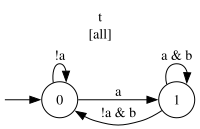

In [2]:
aut

In [4]:
import spot

def count_parameterized_k_lassos(formula_str, k):
    """
    Counts the number of satisfying k-lassos for a given LTL formula.
    k is a natural number parameter limiting the total steps (prefix + loop).
    """
    if k < 1:
        raise ValueError("k must be a natural number greater than 0")

    # 1. Translate the formula to an automaton
    f = spot.formula(formula_str)
    aut = f.translate()
    
    assert aut.is_existential(), "Automaton must be existential/alternating-free"
    
    start_state = aut.get_init_state_number()
    lasso_count = 0
    visited_lassos = set()

    # 2. Bounded DFS exploration
    def dfs(current_state, path, visited_states):
        nonlocal lasso_count
        
        # If the current path length exceeds k, we stop exploring this branch
        if len(path) > k:
            return

        # Check for a loop closure
        if current_state in visited_states:
            loop_start_idx = path.index(current_state)
            prefix = tuple(path[:loop_start_idx])
            loop = tuple(path[loop_start_idx:])
            
            # Total distinct transitions/steps in the lasso = len(prefix) + len(loop)
            # Since path contains the sequence of states up to the repeat, len(path) is our size
            if len(path) <= k:
                lasso_id = (prefix, loop)
                if lasso_id not in visited_lassos:
                    # Verify if the loop satisfies the Büchi acceptance condition
                    if is_loop_accepting(aut, path[loop_start_idx:]):
                        visited_lassos.add(lasso_id)
                        lasso_count += 1
            return

        # Traverse outgoing transitions
        for edge in aut.out(current_state):
            next_state = edge.dst
            
            new_visited = visited_states.copy()
            new_visited.add(current_state)
            
            dfs(next_state, path + [current_state], new_visited)

    def is_loop_accepting(automaton, loop_states):
        # Fix: Call spot.mark_t() directly to initialize an empty acceptance mark
        acc_sets = spot.mark_t() 
        
        for i in range(len(loop_states)):
            src = loop_states[i]
            dst = loop_states[(i + 1) % len(loop_states)]
            
            for edge in automaton.out(src):
                if edge.dst == dst:
                    acc_sets |= edge.acc
                    break
                    
        return automaton.get_acceptance().accepting(acc_sets)

    # Execute search
    dfs(start_state, [], set())
    return lasso_count

# --- Testing the Parameter ---
formula = "F(a) & G(b)"  # Eventually 'a', and 'b' always holds

for parameter_k in range(1, 6):
    count = count_parameterized_k_lassos(formula, k=parameter_k)
    print(f"For k = {parameter_k}, total satisfying lassos: {count}")

For k = 1, total satisfying lassos: 0
For k = 2, total satisfying lassos: 1
For k = 3, total satisfying lassos: 1
For k = 4, total satisfying lassos: 1
For k = 5, total satisfying lassos: 1


In [ ]:
import spot

def count_lasso_bases(formula_str, k):
    """
    Approximates the number of bases w = s0...sk of length k+1
    that can form a lasso trace satisfying the given LTL formula.
    """
    f = spot.formula(formula_str)
    
    # Translate the formula into a deterministic monitor/Büchi automaton
    aut = spot.translate(f, 'ba', 'deterministic')
    
    # Dictionary to keep track of reachable states: {state_id: count_of_paths}
    current_states = {int(aut.get_init_state_number()): 1}
    
    # Track paths of length k (which translates to k+1 states)
    for step in range(k + 1):
        next_states = {}
        for state, path_count in current_states.items():
            for edge in aut.out(state):
                cond = edge.cond
                
                # If the edge condition is false, it's dead/unreachable
                if cond == spot.formula_ff():
                    continue
                
                next_state = int(edge.dst)
                next_states[next_state] = next_states.get(next_state, 0) + path_count
                    
        current_states = next_states

    # Total valid prefixes surviving up to bound k
    return sum(current_states.values())

def semantic_similarity(phi_str, psi_str, k):
    """
    Computes Semantic(phi, psi) = #Approx(phi & psi, k) / #Approx(phi | psi, k)
    """
    and_formula = f"({phi_str}) & ({psi_str})"
    or_formula = f"({phi_str}) | ({psi_str})"
    
    # To find the true set of APs safely, translate the combined formula to an automaton
    # and call .ap() on the automaton object, which returns a list of spot.formula objects
    combined_aut = spot.translate(spot.formula(or_formula), 'ba', 'deterministic')
    variables = [ap.to_str() for ap in combined_aut.ap()]
    
    # Calculate counts
    num_intersection = count_lasso_bases(and_formula, k)
    num_union = count_lasso_bases(or_formula, k)
    
    print(f"Universal variables detected: {variables}")
    print(f"#Approx(φ ∧ ψ, k={k}) = {num_intersection}")
    print(f"#Approx(φ ∨ ψ, k={k}) = {num_union}")
    
    if num_union == 0:
        return 0.0  # Avoid division by zero
        
    return num_intersection / num_union

# --- Example Usage ---
if __name__ == "__main__":
    phi = "G(p -> X(q))"
    psi = "G(p -> F(q))"
    bound_k = 15
    
    similarity = semantic_similarity(phi, psi, bound_k)
    print(f"Semantic Similarity: {similarity:.4f}")

Universal variables detected: ['p', 'q']
#Approx(φ ∧ ψ, k=15) = 65536
#Approx(φ ∨ ψ, k=15) = 65536
Semantic Similarity: 1.0000


In [13]:
import spot
import itertools

def count_lasso_bases(phi_str, variables, k):
    """
    Counts how many base words w of length k+1 can form a satisfying lasso
    trace for the formula phi_str by testing all possible loop-closing indices i.
    """
    f_phi = spot.formula(phi_str)
    aut_phi = spot.translate(f_phi, 'ba', 'deterministic')
    bdd_dict = aut_phi.get_dict()
    
    # Generate all 2^(|AP| * (k+1)) possible concrete base words of length k+1
    state_valuations = []
    for bits in itertools.product([True, False], repeat=len(variables)):
        cond_parts = [var if bit else f"!{var}" for var, bit in zip(variables, bits)]
        state_valuations.append(" & ".join(cond_parts))
    all_bases = list(itertools.product(state_valuations, repeat=k+1))
    
    satisfying_count = 0
    
    for w in all_bases:
        is_satisfiable = False
        # A base w = s0...sk satisfies phi if SOME loop index i makes the lasso valid
        for i in range(k + 1):
            b_aut = spot.make_twa_graph(bdd_dict)
            
            # Create k+1 states
            states = [b_aut.new_state() for _ in range(k + 1)]
            b_aut.set_init_state(states[0])
            
            # Add forward path transitions for s0 -> s1 -> ... -> sk
            for step in range(k):
                cond_f = spot.formula(w[step])
                cond_bdd = spot.formula_to_bdd(cond_f, bdd_dict, b_aut)
                b_aut.new_edge(states[step], states[step+1], cond_bdd)
            
            # Close the loop: sk back to si
            loop_f = spot.formula(w[k])
            loop_bdd = spot.formula_to_bdd(loop_f, bdd_dict, b_aut)
            
            # Set acceptance condition to standard Büchi: 1 acceptance set, Inf(0)
            b_aut.set_acceptance(1, "Inf(0)")
            
            # Mark the loop closing transition as belonging to acceptance set 0 ([0])
            b_aut.new_edge(states[k], states[i], loop_bdd, [0])
            
            # Check language intersection via product emptiness check
            product = spot.product(b_aut, aut_phi)
            if not product.is_empty():
                is_satisfiable = True
                break  # Finding one valid loop index i suffices
                
        if is_satisfiable:
            satisfying_count += 1
            
    return satisfying_count

def semantic_similarity(phi_str, psi_str, k):
    """
    Computes Semantic(phi, psi) = #Approx(phi & psi, k) / #Approx(phi | psi, k)
    """
    and_formula = f"({phi_str}) & ({psi_str})"
    or_formula = f"({phi_str}) | ({psi_str})"
    
    # Extract uniform variables across both formulas
    combined_aut = spot.translate(spot.formula(or_formula), 'ba', 'deterministic')
    variables = [ap.to_str() for ap in combined_aut.ap()]
    
    # Run lasso approximation counts
    num_intersection = count_lasso_bases(and_formula, variables, k)
    num_union = count_lasso_bases(or_formula, variables, k)
    
    print(f"Universal variables detected: {variables}")
    print(f"Total baseline paths analyzed: {2**(len(variables) * (k+1))}")
    print(f"#Approx(φ ∧ ψ, k={k}) = {num_intersection}")
    print(f"#Approx(φ ∨ ψ, k={k}) = {num_union}")
    
    if num_union == 0:
        return 0.0
        
    return num_intersection / num_union

if __name__ == "__main__":
    phi = "G(p -> X(q))"
    psi = "G(p -> F(q))"
    bound_k = 3  
    
    similarity = semantic_similarity(phi, psi, bound_k)
    print(f"Semantic Similarity: {similarity:.4f}")

Universal variables detected: ['p', 'q']
Total baseline paths analyzed: 256
#Approx(φ ∧ ψ, k=3) = 107
#Approx(φ ∨ ψ, k=3) = 241
Semantic Similarity: 0.4440


In [8]:
import spot
from functools import lru_cache

def ast_size(f: spot.formula) -> int:
    """
    Recursively calculates the total number of nodes 
    (operators + propositions) in the LTL formula's AST.
    """
    return 1 + sum(ast_size(child) for child in f)

def _get_node_info(f: spot.formula):
    """Extracts children list and arity of a given formula node."""
    children = list(f)
    return len(children), children

@lru_cache(maxsize=None)
def _raw_mutation_distance(f_str: str, g_str: str) -> float:
    """
    Computes the minimum raw mutation distance between two formulas.
    Uses string representations as cache keys to ensure reliable memoization.
    """
    f = spot.formula(f_str)
    g = spot.formula(g_str)
    
    # Base check for structural equivalence
    if f == g:
        return 0
    
    f_arity, f_children = _get_node_info(f)
    g_arity, g_children = _get_node_info(g)
    
    moves = []
    
    # -------------------------------------------------------------------------
    # STRUCTURAL DELETIONS & INSERTIONS
    # -------------------------------------------------------------------------
    
    # Rule 3b: Unary Deletion from f
    if f_arity == 1:
        moves.append(1 + _raw_mutation_distance(str(f_children[0]), g_str))
        
    # Rule 4b: Binary Subtree Deletion from f (collapsing to left or right branch)
    if f_arity == 2:
        moves.append(1 + _raw_mutation_distance(str(f_children[0]), g_str))
        moves.append(1 + _raw_mutation_distance(str(f_children[1]), g_str))
        
    # Rule 5 / Inverse of Rule 3b: Unary Insertion into f (Deletion from g)
    if g_arity == 1:
        moves.append(1 + _raw_mutation_distance(f_str, str(g_children[0])))
        
    # Inverse of Rule 4b: Binary Insertion into f (Subtree Deletion from g)
    if g_arity == 2:
        moves.append(1 + _raw_mutation_distance(f_str, str(g_children[0])))
        moves.append(1 + _raw_mutation_distance(f_str, str(g_children[1])))

    # Rule 3d: Root Binary Insertion (phi -> p o2 phi)
    # If g is binary and one child is an Atomic Proposition, match f against the other child.
    if g_arity == 2:
        if len(list(g_children[0])) == 0 and not (g_children[0].is_tt() or g_children[0].is_ff()):
            moves.append(1 + _raw_mutation_distance(f_str, str(g_children[1])))
        if len(list(g_children[1])) == 0 and not (g_children[1].is_tt() or g_children[1].is_ff()):
            moves.append(1 + _raw_mutation_distance(f_str, str(g_children[0])))
            
    # Inverse of Rule 3d (Root Binary Insertion on g)
    if f_arity == 2:
        if len(list(f_children[0])) == 0 and not (f_children[0].is_tt() or f_children[0].is_ff()):
            moves.append(1 + _raw_mutation_distance(str(f_children[1]), g_str))
        if len(list(f_children[1])) == 0 and not (f_children[1].is_tt() or f_children[1].is_ff()):
            moves.append(1 + _raw_mutation_distance(str(f_children[0]), g_str))

    # -------------------------------------------------------------------------
    # SUBSTITUTIONS & TRANSPOSITIONS
    # -------------------------------------------------------------------------
    
    # Leaf vs Leaf
    if f_arity == 0 and g_arity == 0:
        # Rule 1: Boolean Flip (true <-> false)
        if (f.is_tt() and g.is_ff()) or (f.is_ff() and g.is_tt()):
            moves.append(1)
        # Rule 2: Proposition Swap (p <-> q)
        elif not (f.is_tt() or f.is_ff()) and not (g.is_tt() or g.is_ff()):
            if str(f) != str(g):
                moves.append(1)
                
    # Unary vs Unary
    if f_arity == 1 and g_arity == 1:
        # Rule 3a: Unary Operator Substitution
        cost = 0 if f.kind() == g.kind() else 1
        moves.append(cost + _raw_mutation_distance(str(f_children[0]), str(g_children[0])))
        
        # Rule 3e: Damerau Unary Transposition (e.g., GF(p) <-> FG(p))
        f_child = f_children[0]
        g_child = g_children[0]
        if len(list(f_child)) == 1 and len(list(g_child)) == 1:
            if f.kind() == g_child.kind() and f_child.kind() == g.kind():
                f_grandchild = list(f_child)[0]
                g_grandchild = list(g_child)[0]
                moves.append(1 + _raw_mutation_distance(str(f_grandchild), str(g_grandchild)))

    # Binary vs Binary
    if f_arity == 2 and g_arity == 2:
        # Rule 4a: Binary Operator Substitution
        cost = 0 if f.kind() == g.kind() else 1
        moves.append(cost + _raw_mutation_distance(str(f_children[0]), str(g_children[0])) 
                          + _raw_mutation_distance(str(f_children[1]), str(g_children[1])))
        
        # Rule 4e: Damerau Binary Transposition (e.g., p U q <-> q U p)
        if f.kind() == g.kind():
            moves.append(1 + _raw_mutation_distance(str(f_children[0]), str(g_children[1]))
                          + _raw_mutation_distance(str(f_children[1]), str(g_children[0])))
            
    return min(moves) if moves else float('inf')


def ltl_mutation_distance(formula_a: str, formula_b: str) -> dict:
    """
    Main user function. Parses string inputs into Spot formulas, 
    calculates raw distance, and applies the Normalization wrapper.
    """
    f = spot.formula(formula_a)
    g = spot.formula(formula_b)
    
    # Calculate sizes
    size_a = ast_size(f)
    size_b = ast_size(g)
    max_size = max(size_a, size_b)
    
    # Calculate raw distance
    raw_dist = _raw_mutation_distance(str(f), str(g))
    
    # Normalize wrapper
    normalized_dist = raw_dist / max_size if max_size > 0 else 0.0
    
    return {
        "formula_a": str(f),
        "formula_b": str(g),
        "size_a": size_a,
        "size_b": size_b,
        "raw_distance": int(raw_dist),
        "normalized_distance": round(normalized_dist, 4)
    }

if __name__ == "__main__":
    test_cases = [
        # Unary Transposition (Rule 3e)
        ("G F p", "F G p"), 
        
        # Binary Transposition (Rule 4e)
        ("p U q", "q U p"), 
        
        # Leaf Substitutions & Flips
        ("p", "q"),
        ("true", "false"),
        
        # Complex structural transformations
        ("G(p -> X q)", "G(p -> q)"), # Unary deletion (X removed)
        ("G(p U q)", "F(q U p)")       # Unary substitution + Binary transposition
    ]
    
    print(f"{'Formula A':<15} | {'Formula B':<15} | {'Size A':<6} | {'Size B':<6} | {'Raw Dist':<8} | {'Norm Dist'}")
    print("-" * 75)
    for fa, fb in test_cases:
        res = ltl_mutation_distance(fa, fb)
        print(f"{res['formula_a']:<15} | {res['formula_b']:<15} | {res['size_a']:<6} | {res['size_b']:<6} | {res['raw_distance']:<8} | {res['normalized_distance']}")

Formula A       | Formula B       | Size A | Size B | Raw Dist | Norm Dist
---------------------------------------------------------------------------
GFp             | FGp             | 3      | 3      | 1        | 0.3333
p U q           | q U p           | 3      | 3      | 1        | 0.3333
p               | q               | 1      | 1      | 1        | 1.0
1               | 0               | 1      | 1      | 1        | 1.0
G(p -> Xq)      | G(p -> q)       | 5      | 4      | 1        | 0.2
G(p U q)        | F(q U p)        | 4      | 4      | 2        | 0.5


In [9]:
res

{'formula_a': 'G(p U q)',
 'formula_b': 'F(q U p)',
 'size_a': 4,
 'size_b': 4,
 'raw_distance': 2,
 'normalized_distance': 0.5}

In [5]:
res

0.3333333333333333

In [21]:
import spot
from collections import deque

# =========================================================
# 1. The Mutation Generator Class
# =========================================================

class LTLMutationGenerator:
    """
    Handles the syntactic transformation of LTL formulas based on 
    a predefined set of substitution, deletion, insertion, and transposition rules.
    """
    
    def __init__(self, ap_list):
        """
        Args:
            ap_list (list of str): The list of valid atomic propositions.
        """
        self.ap_list = ap_list
        # Predefined Spot operator sets
        self.unary_ops = [spot.op_Not, spot.op_X, spot.op_F, spot.op_G]
        self.binary_ops = [spot.op_U, spot.op_W, spot.op_R, spot.op_And, spot.op_Or]

    def _make_unary(self, op_kind, child_formula):
        """Safely builds a unary formula node."""
        if op_kind == spot.op_Not: return spot.formula.Not(child_formula)
        if op_kind == spot.op_X: return spot.formula.X(child_formula)
        if op_kind == spot.op_F: return spot.formula.F(child_formula)
        if op_kind == spot.op_G: return spot.formula.G(child_formula)
        raise ValueError("Invalid unary operator kind")

    def _make_binary(self, op_kind, left, right):
        """Safely builds a binary formula node."""
        if op_kind == spot.op_U: return spot.formula.U(left, right)
        if op_kind == spot.op_W: return spot.formula.W(left, right)
        if op_kind == spot.op_R: return spot.formula.R(left, right)
        if op_kind == spot.op_And: return spot.formula.And([left, right])
        if op_kind == spot.op_Or: return spot.formula.Or([left, right])
        raise ValueError("Invalid binary operator kind")

    def generate_mutations(self, f):
        """
        Inductively yields all single-step valid syntactic mutations 
        for a given LTL formula `f`.
        """
        kind = f.kind()

        # --- GENERAL CASE ---
        # Rule 5: Root Unary Insertion
        for op in self.unary_ops:
            yield self._make_unary(op, f)

        # --- BASE CASES ---
        if kind == spot.op_tt:
            yield spot.formula.ff()                 # Rule 1
        
        elif kind == spot.op_ff:
            yield spot.formula.tt()                 # Rule 1
        
        elif kind == spot.op_ap:
            name = f.ap_name()
            for p in self.ap_list:
                if p != name:
                    yield spot.formula.ap(p)        # Rule 2

        # --- INDUCTIVE CASES: UNARY OPERATORS ---
        elif kind in self.unary_ops:
            child = f[0]

            # Rule 3a: Unary Substitution
            for op in self.unary_ops:
                if op != kind:
                    yield self._make_unary(op, child)
            
            # Rule 3b: Unary Deletion
            yield child

            # Rule 3c: Recursive Mutation
            for mut_child in self.generate_mutations(child):
                yield self._make_unary(kind, mut_child)

            # Rule 3d: Root Binary Insertion
            for p in self.ap_list:
                for op in [spot.op_U, spot.op_W, spot.op_And, spot.op_Or]:
                    yield self._make_binary(op, spot.formula.ap(p), f)

            # Rule 3e: Damerau Unary Transposition
            if child.kind() in self.unary_ops:
                child_kind = child.kind()
                if child_kind != kind:
                    grandchild = child[0]
                    yield self._make_unary(child_kind, self._make_unary(kind, grandchild))

        # --- INDUCTIVE CASES: BINARY OPERATORS ---
        elif kind in self.binary_ops:
            
            # Bridge Spot's N-ary flattened trees (And/Or) to strict binary representation
            left = f[0]
            if f.size() == 2:
                right = f[1]
            else:
                children = [f[i] for i in range(1, f.size())]
                if kind == spot.op_And: right = spot.formula.And(children)
                else: right = spot.formula.Or(children)

            # Rule 4a: Binary Substitution
            for op in self.binary_ops:
                if op != kind:
                    yield self._make_binary(op, left, right)

            # Rule 4b: Subtree Deletion
            yield left
            yield right

            # Rule 4c: Recursive Left
            for mut_left in self.generate_mutations(left):
                yield self._make_binary(kind, mut_left, right)

            # Rule 4d: Recursive Right
            for mut_right in self.generate_mutations(right):
                yield self._make_binary(kind, left, mut_right)

            # Rule 4e: Damerau Binary Transposition
            yield self._make_binary(kind, right, left)


# =========================================================
# 2. The Distance Calculator Class
# =========================================================

# class LTLDistanceCalculator:
#     """
#     Computes the shortest mutation path between two LTL formulas using 
#     Breadth-First Search, wrapping it in a contextual normalization formula.
#     """
    
#     def __init__(self, mutator, max_depth=5):
#         """
#         Args:
#             mutator (LTLMutationGenerator): The engine responsible for generating AST mutations.
#             max_depth (int): The maximum search depth to prevent infinite explosion.
#         """
#         self.mutator = mutator
#         self.max_depth = max_depth

#     def _formula_size(self, f):
#         """Calculates the total node size of the AST recursively."""
#         if f.size() == 0:
#             return 1
#         return 1 + sum(self._formula_size(f[i]) for i in range(f.size()))

#     def calculate_raw_distance(self, phi_a, phi_b):
#         """
#         Computes the absolute minimum mutation steps using BFS.
        
#         Args:
#             phi_a (spot.formula): The starting formula object.
#             phi_b (spot.formula): The target formula object.
#         """
#         target_str = phi_b.to_str()
        
#         # BFS Queue stores tuples: (current_formula, current_distance)
#         queue = deque([(phi_a, 0)])
#         visited = {phi_a.to_str()}

#         while queue:
#             current_f, dist = queue.popleft()

#             # Target reached
#             if current_f.to_str() == target_str:
#                 return dist

#             # Enqueue mutations if within depth limit
            
#             for mutated_f in self.mutator.generate_mutations(current_f):
#                 mut_str = mutated_f.to_str()
#                 if mut_str not in visited:
#                     visited.add(mut_str)
#                     queue.append((mutated_f, dist + 1))

#         return float('inf')

#     def calculate_normalized_distance(self, phi_a_str, phi_b_str):
#         """
#         Applies the Normalization wrapper: Distance / Max(Size(A), Size(B)).
        
#         Args:
#             phi_a_str (str): The starting formula as a string.
#             phi_b_str (str): The target formula as a string.
#         """
#         phi_a = spot.formula(phi_a_str)
#         phi_b = spot.formula(phi_b_str)
        
#         raw_dist = self.calculate_raw_distance(phi_a, phi_b)
        
#         # Handle unreachable targets
#         if raw_dist == float('inf'):
#             return float('inf')

#         max_size = max(self._formula_size(phi_a), self._formula_size(phi_b))
        
#         # Prevent division by zero
#         if max_size == 0:
#             return float('inf')

#         return raw_dist / max_size


class LTLDistanceCalculator:
    def __init__(self, mutator):
        self.mutator = mutator

    def _formula_size(self, f):
        if f.size() == 0: return 1
        return 1 + sum(self._formula_size(f[i]) for i in range(f.size()))

    def calculate_raw_distance(self, phi_a, phi_b):
        if phi_a.to_str() == phi_b.to_str():
            return 0

        # Queues and Visited sets for both directions
        # Stores: (formula_object, distance_from_start)
        queue_f = deque([(phi_a, 0)])
        visited_f = {phi_a.to_str(): 0}
        
        queue_b = deque([(phi_b, 0)])
        visited_b = {phi_b.to_str(): 0}
        
        while queue_f and queue_b:
            # Expand forward
            curr_f, dist_f = queue_f.popleft()
            for neighbor in self.mutator.generate_mutations(curr_f):
                n_str = neighbor.to_str()
                if n_str in visited_b:
                    return dist_f + 1 + visited_b[n_str]
                if n_str not in visited_f:
                    visited_f[n_str] = dist_f + 1
                    queue_f.append((neighbor, dist_f + 1))

            # Expand backward
            curr_b, dist_b = queue_b.popleft()
            for neighbor in self.mutator.generate_mutations(curr_b):
                n_str = neighbor.to_str()
                if n_str in visited_f:
                    return dist_b + 1 + visited_f[n_str]
                if n_str not in visited_b:
                    visited_b[n_str] = dist_b + 1
                    queue_b.append((neighbor, dist_b + 1))
        
        return float('inf')

    def calculate_normalized_distance(self, phi_a_str, phi_b_str):
        phi_a = spot.formula(phi_a_str).unabbreviate("ie")
        phi_b = spot.formula(phi_b_str).unabbreviate("ie")
        raw_dist = self.calculate_raw_distance(phi_a, phi_b)
        
        if raw_dist == float('inf'): return float('inf')

        max_size = max(self._formula_size(phi_a), self._formula_size(phi_b))
        if max_size == 0:
            return float('inf')

        return raw_dist / max_size if max_size > 0 else 0.0

In [24]:
if __name__ == "__main__":
    # 1. Initialize the Generator
    generator = LTLMutationGenerator(ap_list=["p", "q", "r"])
    
    # Optional: You can now use the generator entirely on its own!
    # print("Possible 1-step mutations for 'G(p)':")
    # for mut in generator.generate_mutations(spot.formula("G(p)")):
    #     print(f" - {mut.to_str()}")
    
    # 2. Inject the generator into the Distance Calculator
    distance_calculator = LTLDistanceCalculator(mutator=generator)

    print("--- Test 1: Damerau Unary Transposition ---")
    f1, f2 = "G(F(p))", "F(G(p))"
    dist_unary = distance_calculator.calculate_normalized_distance(f1, f2)
    print(f"Original: {f1} \nMutated:  {f2}")
    print(f"Normalized Distance: {dist_unary:.3f}\n") 

    print("--- Test 2: Damerau Binary Transposition ---")
    f3, f4 = "p U q", "q U p"
    dist_bin = distance_calculator.calculate_normalized_distance(f3, f4)
    print(f"Original: {f3} \nMutated:  {f4}")
    print(f"Normalized Distance: {dist_bin:.3f}\n")
    
    print("--- Test 3: Complex Deletion ---")
    f5, f6 = "G(p) W F(q)", "F(q)"
    dist_del = distance_calculator.calculate_normalized_distance(f5, f6)
    print(f"Original: {f5} \nMutated:  {f6}")
    print(f"Normalized Distance: {dist_del:.3f}")

    print("--- Test 3: Complex Deletion ---")
    f7, f8 = "G(p) R F(q)", "F(q)"
    dist_del = distance_calculator.calculate_normalized_distance(f5, f6)
    print(f"Original: {f5} \nMutated:  {f6}")
    print(f"Normalized Distance: {dist_del:.3f}")

--- Test 1: Damerau Unary Transposition ---
Original: G(F(p)) 
Mutated:  F(G(p))
Normalized Distance: 0.333

--- Test 2: Damerau Binary Transposition ---
Original: p U q 
Mutated:  q U p
Normalized Distance: 0.333

--- Test 3: Complex Deletion ---
Original: G(p) W F(q) 
Mutated:  F(q)
Normalized Distance: 0.200
--- Test 3: Complex Deletion ---
Original: G(p) W F(q) 
Mutated:  F(q)
Normalized Distance: 0.200


In [23]:
def inspect_ast(f, indent=0):
    """
    Recursively prints the AST structure of a Spot formula.
    """
    prefix = "  " * indent
    # Print the current operator/node
    print(f"{prefix}{f.kind()}")
    
    # Recurse into children
    for i in range(f.size()):
        inspect_ast(f[i], indent + 1)

# Usage Example:
f_orig = spot.formula("G(F(p R q))")
f_mutated = spot.formula("F(G(p))")

print("Original AST:")
inspect_ast(f_orig)

print("\nMutated AST:")
inspect_ast(f_mutated)

Original AST:
7
  6
    15
      3
      3

Mutated AST:
6
  7
    3
